# 02 - Color-Locus Robust Linear Regression Audit

Audit notebook for Phase 2 color-locus outputs. The configured CLI pipeline is the source of truth; this notebook reads generated parquet files, reports `strict`/`relaxed` results by astrometric subset, and visualizes robust linear regression diagnostics.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from sklearn.linear_model import HuberRegressor, LinearRegression, RANSACRegressor, TheilSenRegressor
from sklearn.metrics import r2_score

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

with (ROOT / 'configs/filters.yaml').open(encoding='utf-8') as fh:
    filters = yaml.safe_load(fh)
with (ROOT / filters['paths_config']).open(encoding='utf-8') as fh:
    paths = yaml.safe_load(fh)

ref_dir = ROOT / paths['processed_reference_dir']
neg_dir = ROOT / paths['processed_simbad_negative_dir']
variants = filters['color_locus']['dataset_variants']
family_order = list(filters['photometry']['families'])
subset_order = ['photometry', 'parallax_soft', 'poe_1', 'poe_2', 'poe_3', 'poe_5']


def split_variant_name(variant):
    for family in family_order:
        prefix = f'{family}_'
        if variant.startswith(prefix):
            return family, variant[len(prefix):]
    return 'legacy', variant


def variant_metadata(variant):
    family, subset = split_variant_name(variant)
    return {'dataset_variant': variant, 'dataset_family': family, 'astrometric_subset': subset}


def ordered_summary(df):
    out = df.copy()
    out['dataset_family'] = pd.Categorical(out['dataset_family'], family_order, ordered=True)
    out['astrometric_subset'] = pd.Categorical(out['astrometric_subset'], subset_order, ordered=True)
    return out.sort_values(['dataset_family', 'astrometric_subset']).reset_index(drop=True)

color_cfg = filters['color_locus']
planes = [(p['x'], p['y']) for p in color_cfg['candidate_planes']]

from wr_detector.features import (
    inverse_transform_color_values,
    robust_sigma_mad,
    transform_color_values,
)

variants, planes

(['strict_photometry',
  'strict_parallax_soft',
  'strict_poe_1',
  'strict_poe_2',
  'strict_poe_3',
  'strict_poe_5',
  'relaxed_photometry',
  'relaxed_parallax_soft',
  'relaxed_poe_1',
  'relaxed_poe_2',
  'relaxed_poe_3',
  'relaxed_poe_5'],
 [('G_BP', 'G_RP'),
  ('G_BP', 'BP_RP'),
  ('G_RP', 'BP_RP'),
  ('J_H', 'J_K'),
  ('J_K', 'H_K'),
  ('J_H', 'H_K')])

## Current RLR Configuration

The current exported cut is not a hard "keep 95%" rule. It fits each configured color-color plane with Huber regression in `signed_log1p` space, sets each plane threshold to the configured empirical residual quantile, and then marks a row as an aggregate outlier only when it is outside at least `aggregate_min_outlier_planes` planes.

In [2]:
current_rlr_config = {
    'estimator': color_cfg['estimator'],
    'transform': color_cfg['transform'],
    'selection_policy': color_cfg['selection_policy'],
    'threshold_method': color_cfg['threshold_method'],
    'residual_quantile': color_cfg['residual_quantile'],
    'aggregate_min_outlier_planes': color_cfg['aggregate_min_outlier_planes'],
    'residual_sigma_threshold_gamma': color_cfg['residual_sigma_threshold'],
    'candidate_planes': [f'{x} -> {y}' for x, y in planes],
}
current_rlr_config

{'estimator': 'huber',
 'transform': 'signed_log1p',
 'selection_policy': 'all_planes',
 'threshold_method': 'empirical_quantile',
 'residual_quantile': 0.975,
 'aggregate_min_outlier_planes': 2,
 'residual_sigma_threshold_gamma': 2.0,
 'candidate_planes': ['G_BP -> G_RP',
  'G_BP -> BP_RP',
  'G_RP -> BP_RP',
  'J_H -> J_K',
  'J_K -> H_K',
  'J_H -> H_K']}

## Load Color-Locus Outputs

In [3]:
def add_variant_columns(df, variant):
    out = df.copy()
    for key, value in variant_metadata(variant).items():
        if key not in out.columns:
            out[key] = value
    return out


def load_variant_outputs(variant):
    ref_base = pd.read_parquet(ref_dir / filters['output_files'][variant])
    neg_base = pd.read_parquet(neg_dir / filters['simbad_negative_output_files'][variant])
    ref_locus = pd.read_parquet(ref_dir / color_cfg['reference_output_template'].format(variant=variant))
    neg_locus = pd.read_parquet(neg_dir / color_cfg['simbad_negative_output_template'].format(variant=variant))
    return tuple(add_variant_columns(frame, variant) for frame in (ref_base, neg_base, ref_locus, neg_locus))

outputs = {variant: load_variant_outputs(variant) for variant in variants}
load_summary = ordered_summary(pd.DataFrame([
    {
        **variant_metadata(variant),
        'wr_rows': len(frames[0]),
        'simbad_rows': len(frames[1]),
        'wr_locus_rows': len(frames[2]),
        'simbad_locus_rows': len(frames[3]),
    }
    for variant, frames in outputs.items()
]))
load_summary

,dataset_variant,dataset_family,astrometric_subset,wr_rows,simbad_rows,wr_locus_rows,simbad_locus_rows
0,strict_photometry,strict,photometry,306,62659,306,62659
1,strict_parallax_soft,strict,parallax_soft,259,50345,259,50345
2,strict_poe_1,strict,poe_1,222,45721,222,45721
3,strict_poe_2,strict,poe_2,200,43227,200,43227
4,strict_poe_3,strict,poe_3,181,41847,181,41847
5,strict_poe_5,strict,poe_5,146,39422,146,39422
6,relaxed_photometry,relaxed,photometry,347,66787,347,66787
7,relaxed_parallax_soft,relaxed,parallax_soft,298,53773,298,53773
8,relaxed_poe_1,relaxed,poe_1,261,48772,261,48772
9,relaxed_poe_2,relaxed,poe_2,237,45951,237,45951


## Dataset Color Overview

These plots show how the configured photometric and astrometric cuts reshape the WR reference colors before evaluating the locus cuts.

In [4]:
color_columns = ['G_BP', 'G_RP', 'BP_RP', 'J_H', 'J_K', 'H_K', 'W1_W2']
color_summary_rows = []
for variant, (ref_base, _, _, _) in outputs.items():
    for color in color_columns:
        color_summary_rows.append({
            **variant_metadata(variant),
            'color': color,
            'valid_rows': int(ref_base[color].notna().sum()),
            'median': ref_base[color].median(),
            'p05': ref_base[color].quantile(0.05),
            'p95': ref_base[color].quantile(0.95),
        })
color_summary = ordered_summary(pd.DataFrame(color_summary_rows))
color_summary

,dataset_variant,dataset_family,astrometric_subset,color,valid_rows,median,p05,p95
0,strict_photometry,strict,photometry,G_BP,306,-1.488847,-3.621721,-0.171340
1,strict_photometry,strict,photometry,G_RP,306,1.246598,0.396908,1.812994
2,strict_photometry,strict,photometry,BP_RP,306,2.818724,0.572182,5.332294
3,strict_photometry,strict,photometry,J_H,306,0.773500,0.214000,1.800000
4,strict_photometry,strict,photometry,J_K,306,1.414500,0.507250,2.979250
...,...,...,...,...,...,...,...,...
79,relaxed_poe_5,relaxed,poe_5,BP_RP,179,1.686399,0.237309,3.345647
80,relaxed_poe_5,relaxed,poe_5,J_H,179,0.500000,0.127000,1.175600
81,relaxed_poe_5,relaxed,poe_5,J_K,179,0.974999,0.363101,2.240900
82,relaxed_poe_5,relaxed,poe_5,H_K,179,0.484000,0.192600,1.115500


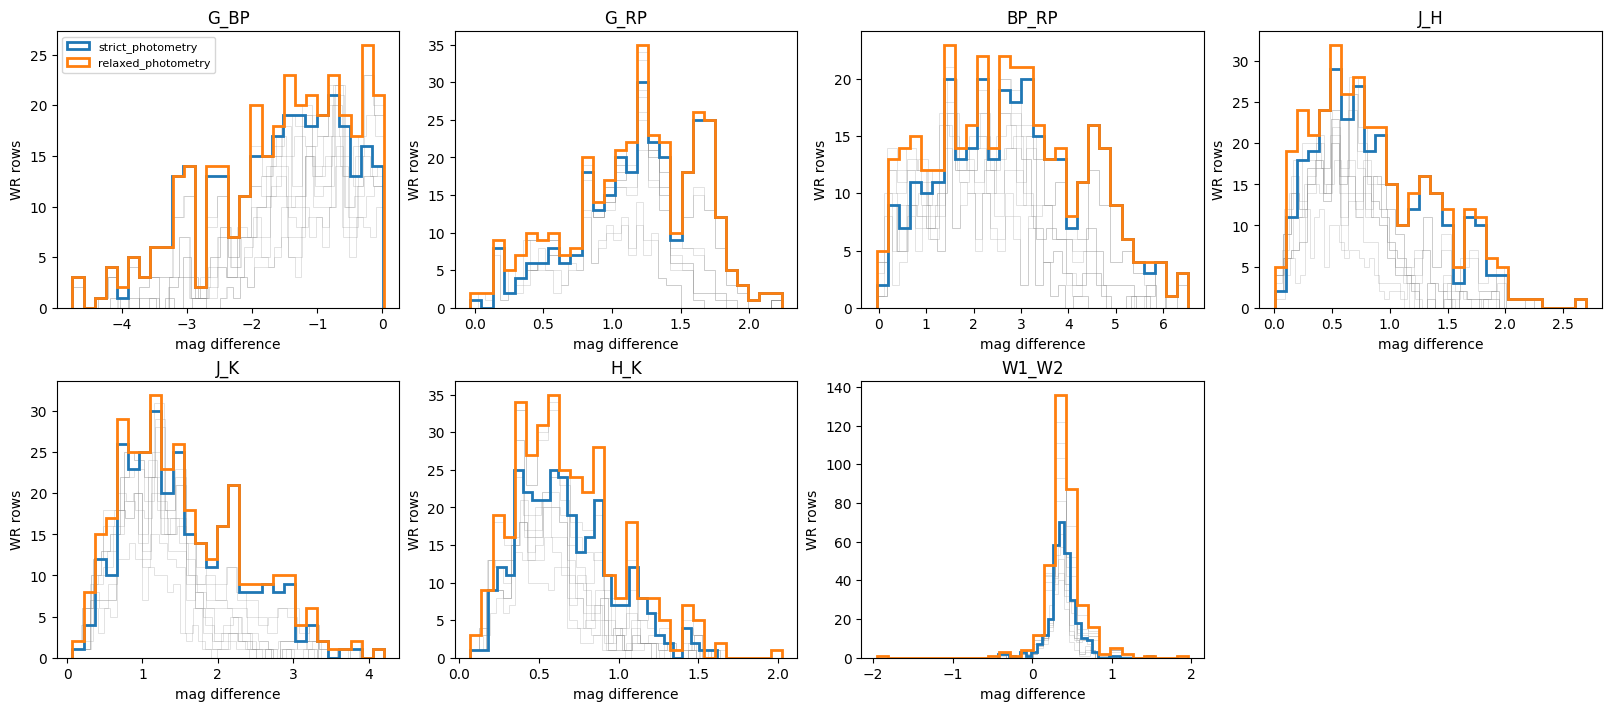

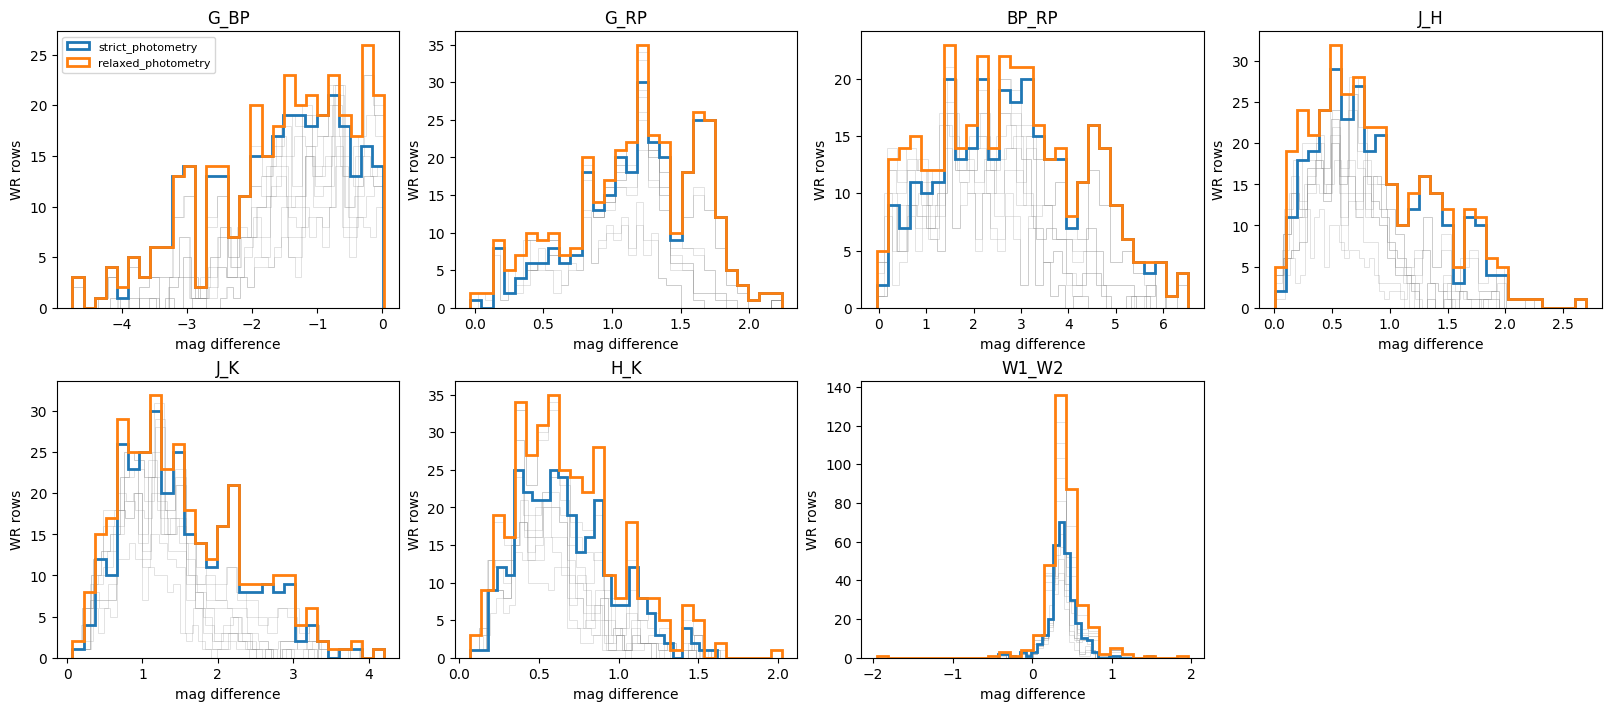

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)
axes = axes.ravel()
main_variants = [v for v in ['strict_photometry', 'relaxed_photometry'] if v in outputs]
context_variants = [v for v in variants if v not in main_variants]
for ax, color in zip(axes, color_columns):
    for variant in context_variants:
        ref_base = outputs[variant][0]
        ax.hist(ref_base[color].dropna(), bins=28, histtype='step', linewidth=0.7, alpha=0.25, color='0.55')
    for variant in main_variants:
        ref_base = outputs[variant][0]
        ax.hist(ref_base[color].dropna(), bins=28, histtype='step', linewidth=2.0, label=variant)
    ax.set_title(color)
    ax.set_xlabel('mag difference')
    ax.set_ylabel('WR rows')
axes[-1].axis('off')
axes[0].legend(fontsize=8)
fig

## Retention Matrix

In [6]:
retention_rows = []
for variant, (_, _, ref_locus, neg_locus) in outputs.items():
    for label, frame in [('wr', ref_locus), ('non_wr_simbad', neg_locus)]:
        retention_rows.append({
            **variant_metadata(variant),
            'sample': label,
            'rows': len(frame),
            'valid': int(frame['color_locus_valid'].sum()),
            'outliers': int(frame['color_locus_outlier'].sum()),
            'kept': int(frame['color_locus_keep'].sum()),
            'kept_fraction': float(frame['color_locus_keep'].mean()),
        })
retention = ordered_summary(pd.DataFrame(retention_rows))
retention

,dataset_variant,dataset_family,astrometric_subset,sample,rows,valid,outliers,kept,kept_fraction
0,strict_photometry,strict,photometry,wr,306,306,14,292,0.954248
1,strict_photometry,strict,photometry,non_wr_simbad,62659,62659,31753,30906,0.493241
2,strict_parallax_soft,strict,parallax_soft,wr,259,259,11,248,0.957529
3,strict_parallax_soft,strict,parallax_soft,non_wr_simbad,50345,50345,24412,25933,0.515106
4,strict_poe_1,strict,poe_1,wr,222,222,10,212,0.954955
5,strict_poe_1,strict,poe_1,non_wr_simbad,45721,45721,22107,23614,0.516480
6,strict_poe_2,strict,poe_2,wr,200,200,8,192,0.960000
7,strict_poe_2,strict,poe_2,non_wr_simbad,43227,43227,22864,20363,0.471071
8,strict_poe_3,strict,poe_3,wr,181,181,8,173,0.955801
9,strict_poe_3,strict,poe_3,non_wr_simbad,41847,41847,20867,20980,0.501350


## Before vs After Color-Locus Cut

`rows` is the dataset size before applying the robust-linear-regression color-locus diagnostic. `kept` is the post-cut size and `outliers` is the number flagged by the aggregate rule. This is the direct before/after accounting for every configured dataset and subdataset.

In [7]:
before_after = retention.copy()
before_after['removed_fraction'] = before_after['outliers'] / before_after['rows']
before_after['kept_fraction'] = before_after['kept'] / before_after['rows']
before_after[[
    'dataset_family',
    'astrometric_subset',
    'sample',
    'rows',
    'kept',
    'outliers',
    'kept_fraction',
    'removed_fraction',
]]

,dataset_family,astrometric_subset,sample,rows,kept,outliers,kept_fraction,removed_fraction
0,strict,photometry,wr,306,292,14,0.954248,0.045752
1,strict,photometry,non_wr_simbad,62659,30906,31753,0.493241,0.506759
2,strict,parallax_soft,wr,259,248,11,0.957529,0.042471
3,strict,parallax_soft,non_wr_simbad,50345,25933,24412,0.515106,0.484894
4,strict,poe_1,wr,222,212,10,0.954955,0.045045
5,strict,poe_1,non_wr_simbad,45721,23614,22107,0.516480,0.483520
6,strict,poe_2,wr,200,192,8,0.960000,0.040000
7,strict,poe_2,non_wr_simbad,43227,20363,22864,0.471071,0.528929
8,strict,poe_3,wr,181,173,8,0.955801,0.044199
9,strict,poe_3,non_wr_simbad,41847,20980,20867,0.501350,0.498650


In [8]:
wr_before_after = before_after[before_after['sample'] == 'wr'].copy()
simbad_before_after = before_after[before_after['sample'] == 'non_wr_simbad'].copy()
wr_before_after.pivot(index='astrometric_subset', columns='dataset_family', values=['rows', 'kept', 'outliers']).loc[subset_order]

rows           kept         outliers        
dataset_family     strict relaxed strict relaxed   strict relaxed
astrometric_subset                                               
photometry            306     347    292     331       14      16
parallax_soft         259     298    248     284       11      14
poe_1                 222     261    212     249       10      12
poe_2                 200     237    192     227        8      10
poe_3                 181     218    173     208        8      10
poe_5                 146     179    140     170        6       9

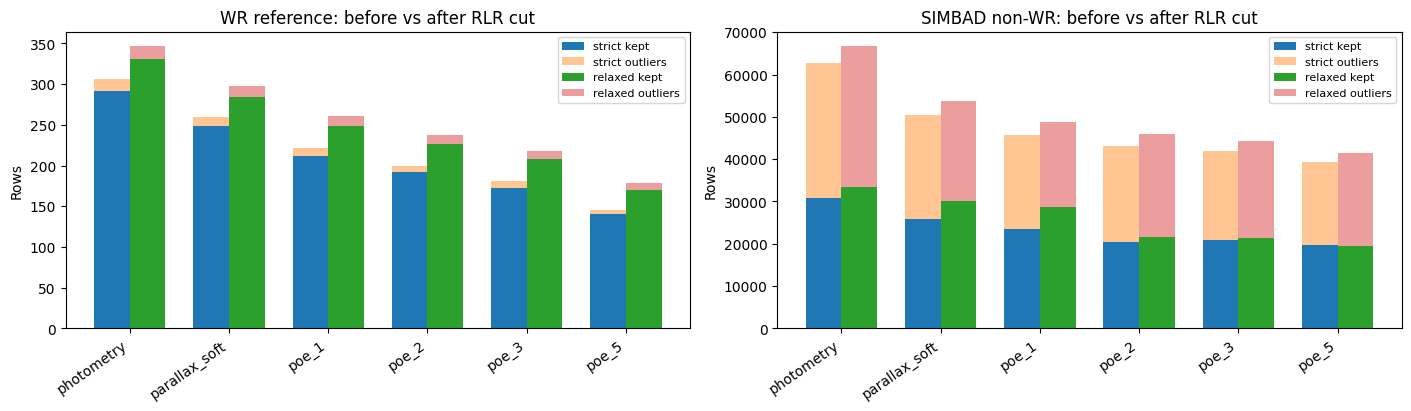

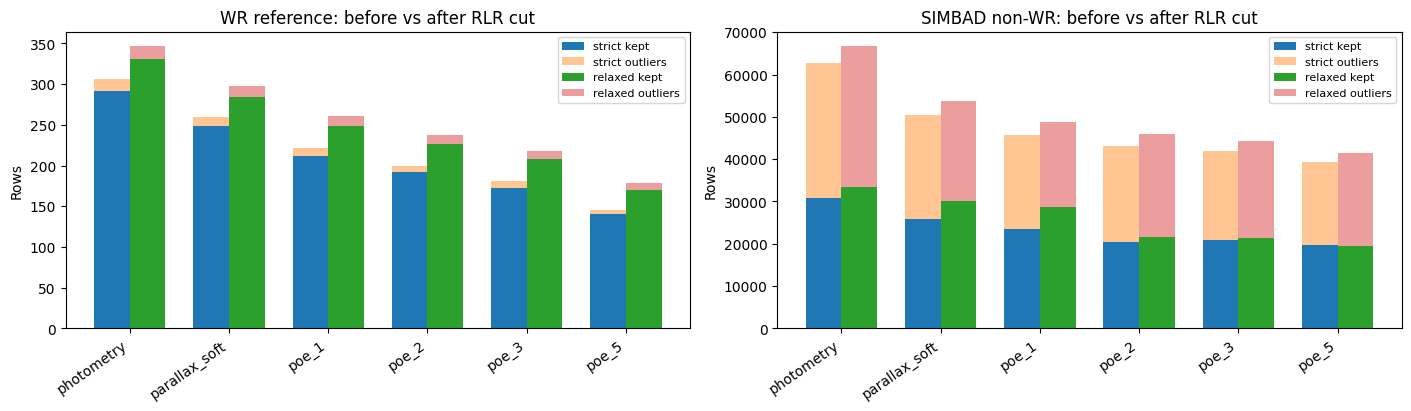

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
for ax, (sample_name, sample_df) in zip(axes, [('WR reference', wr_before_after), ('SIMBAD non-WR', simbad_before_after)]):
    x = np.arange(len(subset_order))
    width = 0.36
    for offset, family in [(-width / 2, 'strict'), (width / 2, 'relaxed')]:
        fam = sample_df[sample_df['dataset_family'] == family].set_index('astrometric_subset').loc[subset_order]
        ax.bar(x + offset, fam['kept'], width, label=f'{family} kept')
        ax.bar(x + offset, fam['outliers'], width, bottom=fam['kept'], alpha=0.45, label=f'{family} outliers')
    ax.set_xticks(x)
    ax.set_xticklabels(subset_order, rotation=35, ha='right')
    ax.set_title(f'{sample_name}: before vs after RLR cut')
    ax.set_ylabel('Rows')
    ax.legend(fontsize=8)
fig

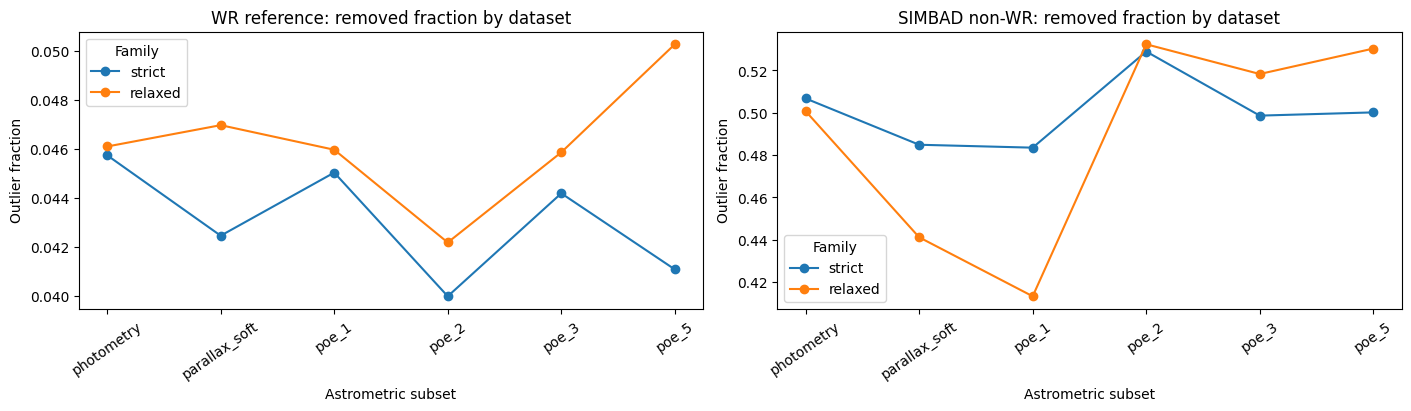

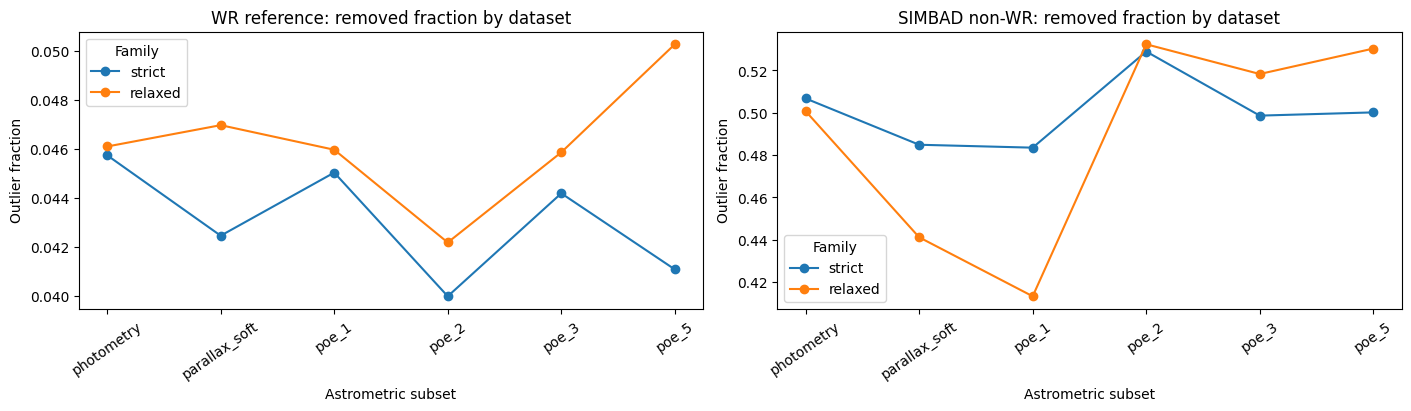

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
for ax, (sample_name, sample_df) in zip(axes, [('WR reference', wr_before_after), ('SIMBAD non-WR', simbad_before_after)]):
    for family in family_order:
        fam = sample_df[sample_df['dataset_family'] == family].set_index('astrometric_subset').loc[subset_order]
        ax.plot(fam.index.astype(str), fam['removed_fraction'], marker='o', label=family)
    ax.set_title(f'{sample_name}: removed fraction by dataset')
    ax.set_xlabel('Astrometric subset')
    ax.set_ylabel('Outlier fraction')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Family')
fig

In [11]:
wr_retention = retention[retention['sample'] == 'wr'].pivot(index='astrometric_subset', columns='dataset_family', values='kept_fraction').loc[subset_order]
simbad_retention = retention[retention['sample'] == 'non_wr_simbad'].pivot(index='astrometric_subset', columns='dataset_family', values='kept_fraction').loc[subset_order]
wr_retention, simbad_retention

(dataset_family        strict   relaxed
 astrometric_subset                    
 photometry          0.954248  0.953890
 parallax_soft       0.957529  0.953020
 poe_1               0.954955  0.954023
 poe_2               0.960000  0.957806
 poe_3               0.955801  0.954128
 poe_5               0.958904  0.949721,
 dataset_family        strict   relaxed
 astrometric_subset                    
 photometry          0.493241  0.499244
 parallax_soft       0.515106  0.558812
 poe_1               0.516480  0.586669
 poe_2               0.471071  0.467650
 poe_3               0.501350  0.481697
 poe_5               0.499822  0.469683)

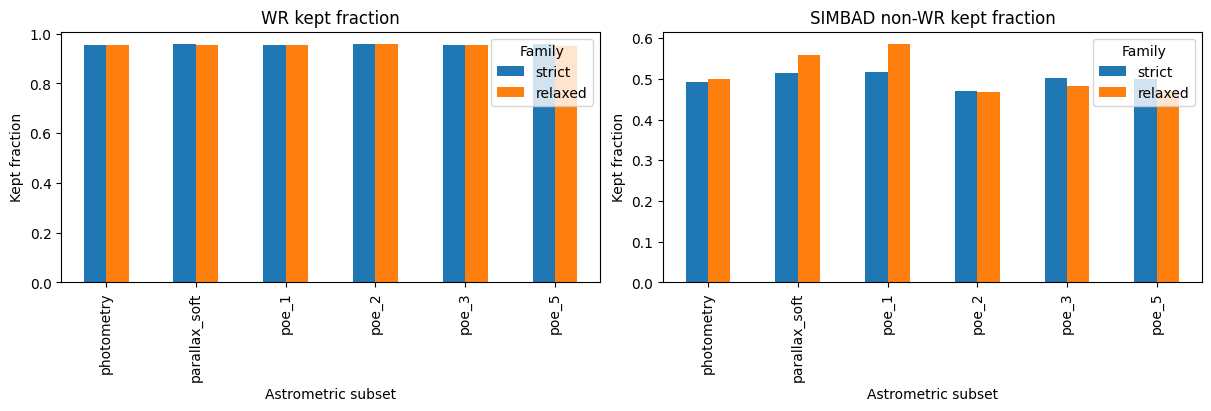

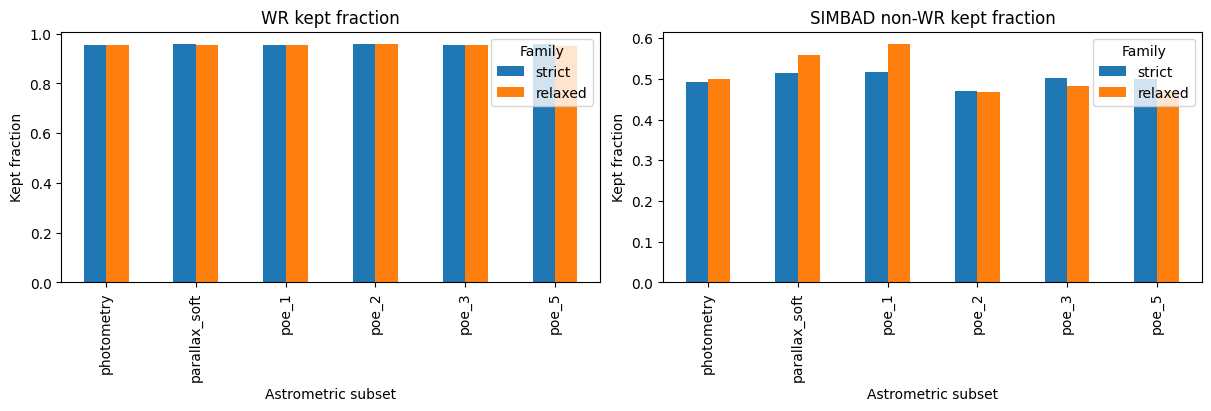

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
wr_retention.plot(kind='bar', ax=axes[0])
simbad_retention.plot(kind='bar', ax=axes[1])
axes[0].set_title('WR kept fraction')
axes[1].set_title('SIMBAD non-WR kept fraction')
for ax in axes:
    ax.set_xlabel('Astrometric subset')
    ax.set_ylabel('Kept fraction')
    ax.legend(title='Family')
fig

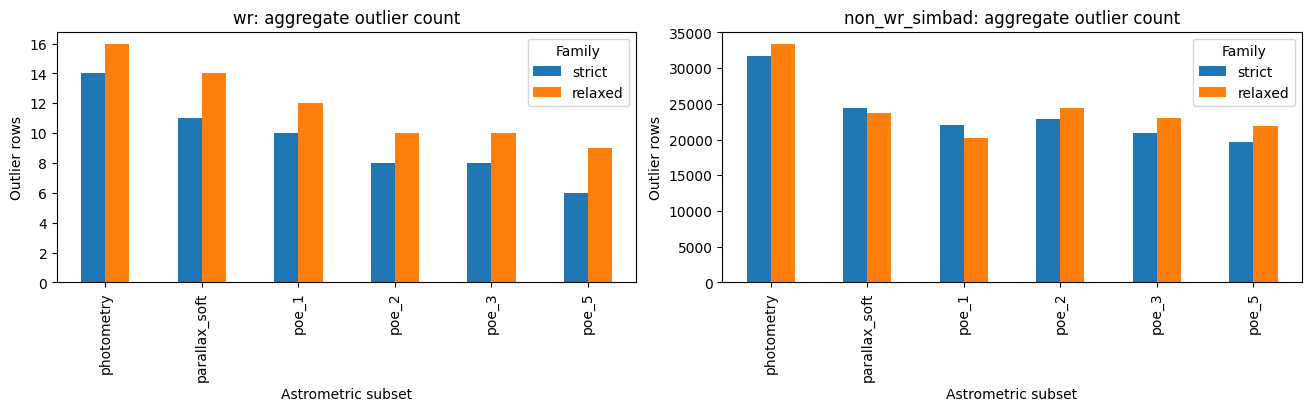

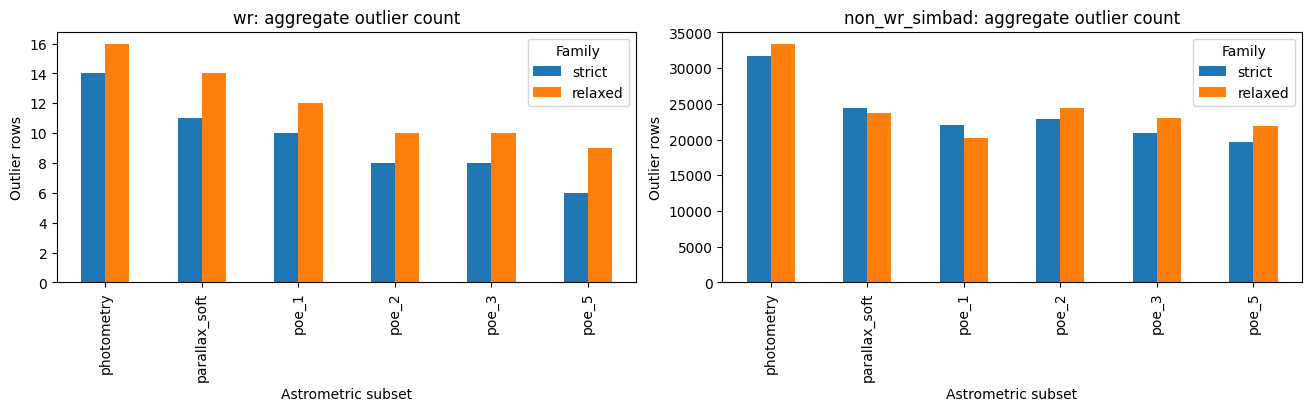

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for sample, ax in [('wr', axes[0]), ('non_wr_simbad', axes[1])]:
    subset = retention[retention['sample'] == sample]
    pivot = subset.pivot(index='astrometric_subset', columns='dataset_family', values='outliers').loc[subset_order]
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'{sample}: aggregate outlier count')
    ax.set_xlabel('Astrometric subset')
    ax.set_ylabel('Outlier rows')
    ax.legend(title='Family')
fig

In [14]:
plane_count_rows = []
for variant, (_, _, ref_locus, neg_locus) in outputs.items():
    for label, frame in [('wr', ref_locus), ('non_wr_simbad', neg_locus)]:
        counts = frame['color_locus_outlier_plane_count'].value_counts().sort_index()
        for plane_count, rows in counts.items():
            plane_count_rows.append({
                **variant_metadata(variant),
                'sample': label,
                'outlier_plane_count': int(plane_count),
                'rows': int(rows),
                'fraction': rows / len(frame),
            })
plane_count_summary = ordered_summary(pd.DataFrame(plane_count_rows))
plane_count_summary

,dataset_variant,dataset_family,astrometric_subset,sample,outlier_plane_count,rows,fraction
0,strict_photometry,strict,photometry,wr,0,284,0.928105
1,strict_photometry,strict,photometry,wr,1,8,0.026144
2,strict_photometry,strict,photometry,wr,2,6,0.019608
3,strict_photometry,strict,photometry,wr,3,5,0.016340
4,strict_photometry,strict,photometry,wr,4,2,0.006536
...,...,...,...,...,...,...,...
148,relaxed_poe_5,relaxed,poe_5,non_wr_simbad,2,11349,0.274270
149,relaxed_poe_5,relaxed,poe_5,non_wr_simbad,3,10350,0.250127
150,relaxed_poe_5,relaxed,poe_5,non_wr_simbad,4,140,0.003383
151,relaxed_poe_5,relaxed,poe_5,non_wr_simbad,5,69,0.001668


## Robust Linear Regression Metrics

In [15]:
fit_rows = []
for variant, (_, _, ref_locus, _) in outputs.items():
    for x_color, y_color in planes:
        plane_name = f'{x_color}__{y_color}'.replace('-', '_')
        slope_col = f'color_locus_{plane_name}_slope'
        if slope_col not in ref_locus.columns:
            continue
        fit_rows.append({
            **variant_metadata(variant),
            'plane': f'{x_color} -> {y_color}',
            'n_valid': int(ref_locus[f'color_locus_{plane_name}_valid'].sum()),
            'outlier_rows': int(ref_locus[f'color_locus_{plane_name}_outlier'].sum()),
            'slope': ref_locus[slope_col].iloc[0],
            'intercept': ref_locus[f'color_locus_{plane_name}_intercept'].iloc[0],
            'r2': ref_locus[f'color_locus_{plane_name}_r2'].iloc[0],
            'sigma_mad': ref_locus[f'color_locus_{plane_name}_sigma_mad'].iloc[0],
            'threshold': ref_locus[f'color_locus_{plane_name}_threshold'].iloc[0],
        })
fits = ordered_summary(pd.DataFrame(fit_rows))
fits.sort_values(['dataset_family', 'astrometric_subset', 'plane'])

,dataset_variant,dataset_family,astrometric_subset,plane,n_valid,outlier_rows,slope,intercept,r2,sigma_mad,threshold
1,strict_photometry,strict,photometry,G_BP -> BP_RP,306,8,-0.940133,0.433696,0.959238,0.026939,0.282030
0,strict_photometry,strict,photometry,G_BP -> G_RP,306,8,-0.424930,0.383813,0.774765,0.038075,0.307771
2,strict_photometry,strict,photometry,G_RP -> BP_RP,306,8,1.946116,-0.216630,0.909724,0.060467,0.398604
5,strict_photometry,strict,photometry,J_H -> H_K,306,8,0.599295,0.130167,0.711866,0.067406,0.231462
3,strict_photometry,strict,photometry,J_H -> J_K,306,8,1.139375,0.204593,0.950547,0.043962,0.171344
...,...,...,...,...,...,...,...,...,...,...,...
66,relaxed_poe_5,relaxed,poe_5,G_BP -> G_RP,179,5,-0.586884,0.261012,0.890490,0.049320,0.184154
68,relaxed_poe_5,relaxed,poe_5,G_RP -> BP_RP,179,5,1.794447,-0.131700,0.977943,0.039082,0.134627
71,relaxed_poe_5,relaxed,poe_5,J_H -> H_K,179,5,0.697047,0.116629,0.593597,0.104664,0.241739
69,relaxed_poe_5,relaxed,poe_5,J_H -> J_K,179,5,1.258478,0.166352,0.898084,0.076228,0.197790


## Subdataset Result Tables

The detailed plots above focus on the parent photometry datasets. The following tables summarize the same RLR outputs across every configured astrometric subdataset.

In [16]:
fit_table = fits.pivot_table(
    index=['dataset_family', 'astrometric_subset'],
    columns='plane',
    values='r2',
    aggfunc='first',
).reset_index()
fit_table

plane,dataset_family,astrometric_subset,G_BP -> BP_RP,G_BP -> G_RP,G_RP -> BP_RP,J_H -> H_K,J_H -> J_K,J_K -> H_K
0,strict,photometry,0.959238,0.774765,0.909724,0.711866,0.950547,0.883221
1,strict,parallax_soft,0.967206,0.842720,0.944715,0.668964,0.939279,0.869152
2,strict,poe_1,0.963824,0.846372,0.952144,0.551424,0.911045,0.822764
3,strict,poe_2,0.967273,0.886021,0.971033,0.547581,0.898959,0.834802
4,strict,poe_3,0.965837,0.883070,0.971637,0.524544,0.890017,0.828208
5,strict,poe_5,0.962392,0.885160,0.976407,0.441420,0.857045,0.804294
6,relaxed,photometry,0.960195,0.803251,0.927404,0.722244,0.950630,0.888904
7,relaxed,parallax_soft,0.966978,0.856828,0.953232,0.698465,0.942631,0.882982
8,relaxed,poe_1,0.964514,0.859448,0.958605,0.636435,0.925522,0.861685
9,relaxed,poe_2,0.967563,0.891467,0.973710,0.638798,0.918582,0.871628


In [17]:
sigma_table = fits.pivot_table(
    index=['dataset_family', 'astrometric_subset'],
    columns='plane',
    values='sigma_mad',
    aggfunc='first',
).reset_index()
sigma_table

plane,dataset_family,astrometric_subset,G_BP -> BP_RP,G_BP -> G_RP,G_RP -> BP_RP,J_H -> H_K,J_H -> J_K,J_K -> H_K
0,strict,photometry,0.026939,0.038075,0.060467,0.067406,0.043962,0.047437
1,strict,parallax_soft,0.027572,0.033100,0.055161,0.071554,0.050675,0.052948
2,strict,poe_1,0.024414,0.029459,0.045112,0.081930,0.059275,0.053715
3,strict,poe_2,0.027603,0.033919,0.042785,0.084162,0.063854,0.057052
4,strict,poe_3,0.028866,0.033186,0.042610,0.089075,0.064590,0.062740
5,strict,poe_5,0.034263,0.035352,0.035073,0.091357,0.070366,0.063189
6,relaxed,photometry,0.035174,0.044789,0.063482,0.074871,0.054067,0.054888
7,relaxed,parallax_soft,0.034402,0.041611,0.059352,0.085234,0.058729,0.059035
8,relaxed,poe_1,0.036032,0.040502,0.051889,0.091972,0.065404,0.066705
9,relaxed,poe_2,0.040748,0.044276,0.049857,0.097594,0.066749,0.069826


In [18]:
retention_table = retention.pivot_table(
    index=['dataset_family', 'astrometric_subset'],
    columns='sample',
    values=['rows', 'outliers', 'kept', 'kept_fraction'],
    aggfunc='first',
).reset_index()
retention_table

dataset_family astrometric_subset          kept      kept_fraction  \
sample                                   non_wr_simbad   wr non_wr_simbad   
0              strict         photometry         30906  292      0.493241   
1              strict      parallax_soft         25933  248      0.515106   
2              strict              poe_1         23614  212      0.516480   
3              strict              poe_2         20363  192      0.471071   
4              strict              poe_3         20980  173      0.501350   
5              strict              poe_5         19704  140      0.499822   
6             relaxed         photometry         33343  331      0.499244   
7             relaxed      parallax_soft         30049  284      0.558812   
8             relaxed              poe_1         28613  249      0.586669   
9             relaxed              poe_2         21489  227      0.467650   
10            relaxed              poe_3         21344  208      0.481697   
11            relaxed              poe_5         19435  170      0.469683   

                      outliers              rows       
sample        wr non_wr_simbad  wr non_wr_simbad   wr  
0       0.954248         31753  14         62659  306  
1       0.957529         24412  11         50345  259  
2       0.954955         22107  10         45721  222  
3       0.960000         22864   8         43227  200  
4       0.955801         20867   8         41847  181  
5       0.958904         19718   6         39422  146  
6       0.953890         33444  16         66787  347  
7       0.953020         23724  14         53773  298  
8       0.954023         20159  12         48772  261  
9       0.957806         24462  10         45951  237  
10      0.954128         22966  10         44310  218  
11      0.949721         21944   9         41379  179

## Threshold Behavior: Quantile vs Gamma

The exported pipeline currently uses `empirical_quantile`, so `residual_sigma_threshold` is metadata for sigma-MAD mode rather than the active per-plane threshold. This table compares how many WR rows each threshold rule would flag per plane for the same fitted Huber model.

In [19]:
threshold_rows = []
quantiles_to_check = [0.95, 0.975, 0.99]
gammas_to_check = [2.0, 2.5, 3.0]
for variant, (_, _, ref_locus, _) in outputs.items():
    for x_color, y_color in planes:
        plane_name = f'{x_color}__{y_color}'.replace('-', '_')
        residual_col = f'color_locus_{plane_name}_residual'
        sigma_col = f'color_locus_{plane_name}_sigma_mad'
        threshold_col = f'color_locus_{plane_name}_threshold'
        if residual_col not in ref_locus.columns:
            continue
        residual_abs = ref_locus[residual_col].abs().dropna()
        sigma = float(ref_locus[sigma_col].iloc[0])
        exported_threshold = float(ref_locus[threshold_col].iloc[0])
        for q in quantiles_to_check:
            threshold = float(residual_abs.quantile(q))
            threshold_rows.append({
                **variant_metadata(variant),
                'plane': f'{x_color} -> {y_color}',
                'threshold_rule': f'empirical_q{q}',
                'threshold': threshold,
                'wr_outlier_fraction': float((residual_abs > threshold).mean()),
            })
        for gamma in gammas_to_check:
            threshold = gamma * sigma
            threshold_rows.append({
                **variant_metadata(variant),
                'plane': f'{x_color} -> {y_color}',
                'threshold_rule': f'gamma_{gamma}_sigma_mad',
                'threshold': threshold,
                'wr_outlier_fraction': float((residual_abs > threshold).mean()),
            })
        threshold_rows.append({
            **variant_metadata(variant),
            'plane': f'{x_color} -> {y_color}',
            'threshold_rule': 'exported_current',
            'threshold': exported_threshold,
            'wr_outlier_fraction': float((residual_abs > exported_threshold).mean()),
        })
threshold_grid = ordered_summary(pd.DataFrame(threshold_rows))
threshold_grid

,dataset_variant,dataset_family,astrometric_subset,plane,threshold_rule,threshold,wr_outlier_fraction
0,strict_photometry,strict,photometry,G_BP -> G_RP,empirical_q0.95,0.257029,0.052288
1,strict_photometry,strict,photometry,G_BP -> G_RP,empirical_q0.975,0.307771,0.026144
2,strict_photometry,strict,photometry,G_BP -> G_RP,empirical_q0.99,0.336211,0.013072
3,strict_photometry,strict,photometry,G_BP -> G_RP,gamma_2.0_sigma_mad,0.076150,0.235294
4,strict_photometry,strict,photometry,G_BP -> G_RP,gamma_2.5_sigma_mad,0.095188,0.202614
...,...,...,...,...,...,...,...
499,relaxed_poe_5,relaxed,poe_5,J_H -> H_K,empirical_q0.99,0.261668,0.011173
500,relaxed_poe_5,relaxed,poe_5,J_H -> H_K,gamma_2.0_sigma_mad,0.209328,0.055866
501,relaxed_poe_5,relaxed,poe_5,J_H -> H_K,gamma_2.5_sigma_mad,0.261660,0.011173
502,relaxed_poe_5,relaxed,poe_5,J_H -> H_K,gamma_3.0_sigma_mad,0.313992,0.000000


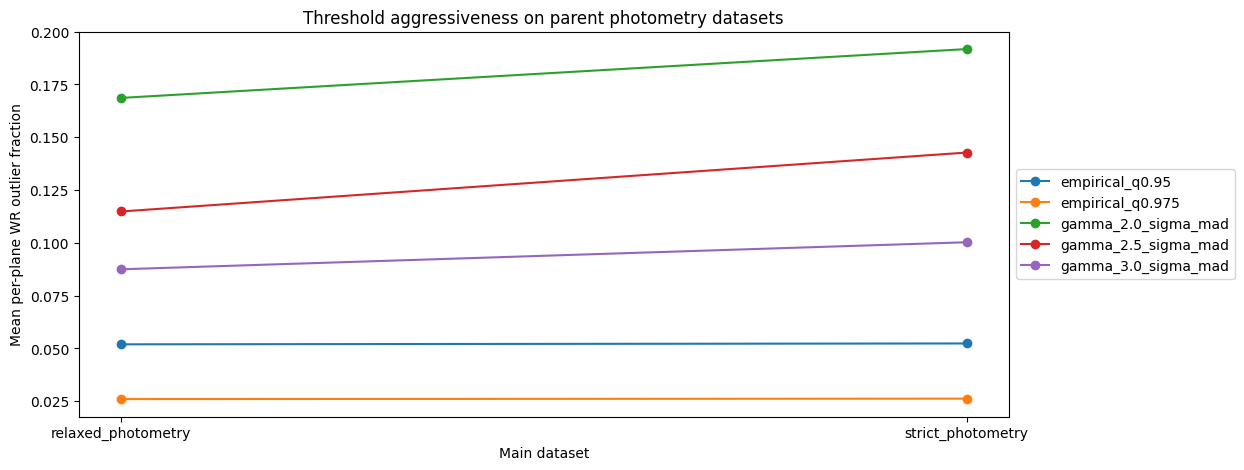

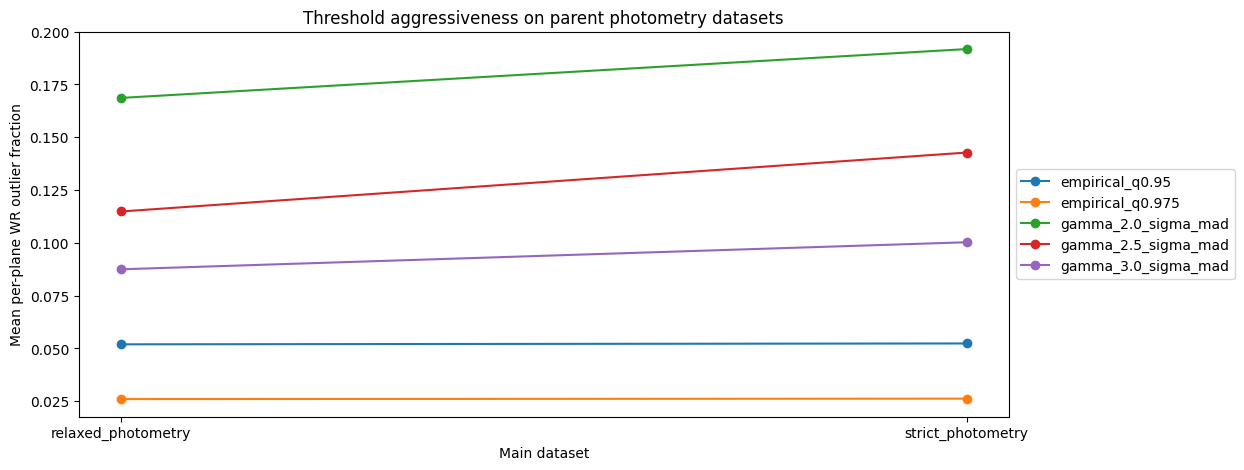

In [20]:
focus_thresholds = threshold_grid[
    (threshold_grid['dataset_variant'].isin(['strict_photometry', 'relaxed_photometry']))
    & (threshold_grid['threshold_rule'].isin(['empirical_q0.95', 'empirical_q0.975', 'gamma_2.0_sigma_mad', 'gamma_2.5_sigma_mad', 'gamma_3.0_sigma_mad']))
]
fig, ax = plt.subplots(figsize=(12, 5))
for rule, group in focus_thresholds.groupby('threshold_rule'):
    values = group.groupby('dataset_variant')['wr_outlier_fraction'].mean().sort_index()
    ax.plot(values.index, values.values, marker='o', label=rule)
ax.set_xlabel('Main dataset')
ax.set_ylabel('Mean per-plane WR outlier fraction')
ax.set_title('Threshold aggressiveness on parent photometry datasets')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig

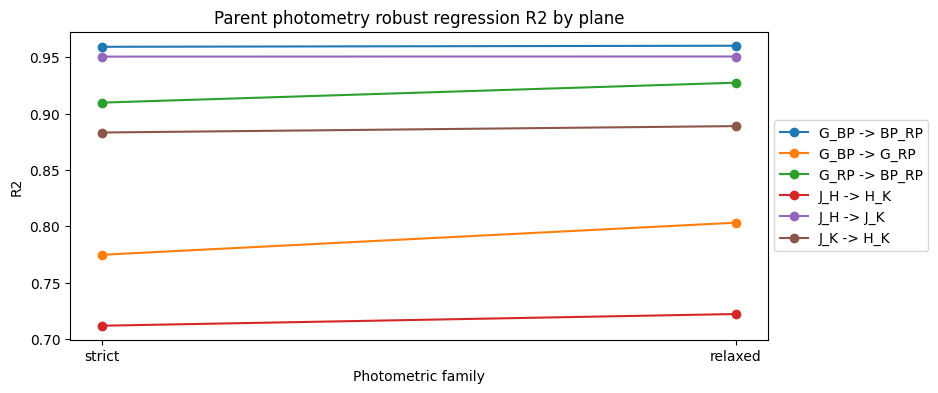

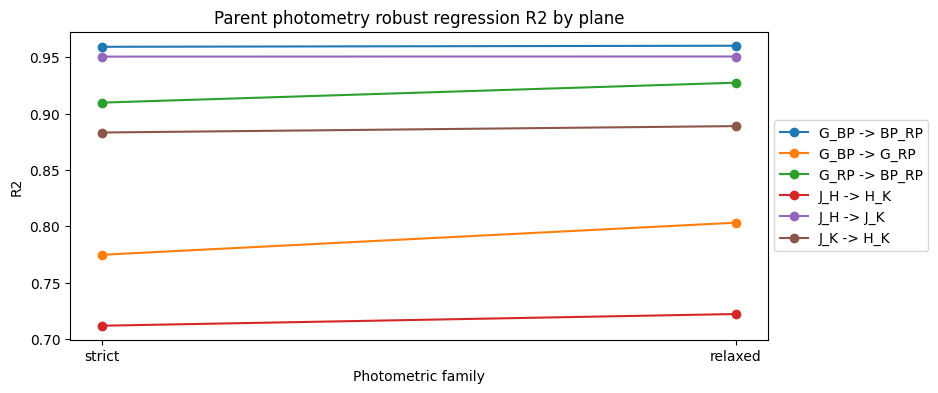

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
for plane, group in fits[fits['astrometric_subset'] == 'photometry'].groupby('plane'):
    group = group.sort_values('dataset_family')
    ax.plot(group['dataset_family'].astype(str), group['r2'], marker='o', label=plane)
ax.set_xlabel('Photometric family')
ax.set_ylabel('R2')
ax.set_title('Parent photometry robust regression R2 by plane')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig

## Estimator Comparison Sandbox

Why this is here: Huber regression is the current pipeline choice, but the cut depends on the fitted locus and residual scale. I added `linear`, `theil_sen`, and `ransac` as a diagnostic comparison to check whether Huber is unusually sensitive or whether a different robust estimator would materially change the locus. These results are exploratory only; the exported parquet files still come from the configured Huber pipeline.

Interpretation guide: higher `R2` means tighter transformed color-color relation, lower `sigma_mad` means smaller robust residual scale, and the outlier-fraction columns show how aggressive each estimator would be under either empirical-q97.5 or gamma=2 sigma-MAD thresholds.

In [22]:
def make_estimator(name):
    if name == 'linear':
        return LinearRegression()
    if name == 'huber':
        return HuberRegressor()
    if name == 'theil_sen':
        return TheilSenRegressor(random_state=42)
    if name == 'ransac':
        return RANSACRegressor(estimator=LinearRegression(), random_state=42)
    raise ValueError(name)


def fit_estimator_metrics(df, x_color, y_color, estimator_name):
    valid = df[x_color].notna() & df[y_color].notna()
    x = transform_color_values(df.loc[valid, x_color], transform=color_cfg['transform']).to_numpy().reshape(-1, 1)
    y = transform_color_values(df.loc[valid, y_color], transform=color_cfg['transform']).to_numpy()
    estimator = make_estimator(estimator_name)
    estimator.fit(x, y)
    pred = estimator.predict(x)
    residual = y - pred
    if estimator_name == 'ransac':
        base = estimator.estimator_
        slope = float(base.coef_[0])
        intercept = float(base.intercept_)
    else:
        slope = float(estimator.coef_[0])
        intercept = float(estimator.intercept_)
    sigma = robust_sigma_mad(residual)
    return {
        'n': int(valid.sum()),
        'slope': slope,
        'intercept': intercept,
        'r2': float(r2_score(y, pred)),
        'sigma_mad': sigma,
        'q975_threshold': float(np.quantile(np.abs(residual), 0.975)),
        'gamma2_threshold': float(2.0 * sigma),
        'q975_outlier_fraction': float((np.abs(residual) > np.quantile(np.abs(residual), 0.975)).mean()),
        'gamma2_outlier_fraction': float((np.abs(residual) > 2.0 * sigma).mean()),
    }

estimator_rows = []
for variant in [v for v in ['strict_poe_3', 'relaxed_poe_3', 'strict_photometry', 'relaxed_photometry'] if v in outputs]:
    ref_base = outputs[variant][0]
    for x_color, y_color in planes:
        for estimator_name in ['linear', 'huber', 'theil_sen', 'ransac']:
            try:
                metrics = fit_estimator_metrics(ref_base, x_color, y_color, estimator_name)
            except Exception as exc:
                metrics = {'error': str(exc)}
            estimator_rows.append({
                **variant_metadata(variant),
                'plane': f'{x_color} -> {y_color}',
                'estimator': estimator_name,
                **metrics,
            })
estimator_comparison = ordered_summary(pd.DataFrame(estimator_rows))
estimator_comparison

,dataset_variant,dataset_family,astrometric_subset,plane,estimator,n,slope,intercept,r2,sigma_mad,q975_threshold,gamma2_threshold,q975_outlier_fraction,gamma2_outlier_fraction
0,strict_photometry,strict,photometry,G_BP -> G_RP,linear,306,-0.459529,0.358029,0.779768,0.044566,0.313854,0.089131,0.026144,0.215686
1,strict_photometry,strict,photometry,G_BP -> G_RP,huber,306,-0.424930,0.383813,0.774765,0.038075,0.307771,0.076150,0.026144,0.235294
2,strict_photometry,strict,photometry,G_BP -> G_RP,theil_sen,306,-0.428301,0.392372,0.775357,0.036906,0.296752,0.073812,0.026144,0.274510
3,strict_photometry,strict,photometry,G_BP -> G_RP,ransac,306,-0.383804,0.423082,0.758405,0.034345,0.310969,0.068690,0.026144,0.271242
4,strict_photometry,strict,photometry,G_BP -> BP_RP,linear,306,-0.992693,0.382846,0.962005,0.038947,0.243863,0.077893,0.026144,0.173203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,relaxed_poe_3,relaxed,poe_3,J_K -> H_K,ransac,218,0.638094,-0.041143,0.868500,0.066312,0.139447,0.132623,0.027523,0.036697
92,relaxed_poe_3,relaxed,poe_3,J_H -> H_K,linear,218,0.642107,0.143933,0.640345,0.098047,0.220013,0.196094,0.027523,0.059633
93,relaxed_poe_3,relaxed,poe_3,J_H -> H_K,huber,218,0.685907,0.113312,0.633531,0.102902,0.236415,0.205804,0.027523,0.055046
94,relaxed_poe_3,relaxed,poe_3,J_H -> H_K,theil_sen,218,0.624436,0.126221,0.618115,0.096374,0.233772,0.192747,0.027523,0.082569


In [23]:
estimator_summary = estimator_comparison.groupby(['dataset_variant', 'dataset_family', 'astrometric_subset', 'estimator'], observed=False).agg(
    mean_r2=('r2', 'mean'),
    median_r2=('r2', 'median'),
    mean_sigma_mad=('sigma_mad', 'mean'),
    median_sigma_mad=('sigma_mad', 'median'),
    mean_q975_outlier_fraction=('q975_outlier_fraction', 'mean'),
    mean_gamma2_outlier_fraction=('gamma2_outlier_fraction', 'mean'),
).reset_index()
estimator_summary = ordered_summary(estimator_summary)
estimator_summary

,dataset_variant,dataset_family,astrometric_subset,estimator,mean_r2,median_r2,mean_sigma_mad,median_sigma_mad,mean_q975_outlier_fraction,mean_gamma2_outlier_fraction
0,relaxed_photometry,strict,photometry,huber,NaN,NaN,NaN,NaN,NaN,NaN
1,relaxed_photometry,strict,photometry,linear,NaN,NaN,NaN,NaN,NaN,NaN
2,relaxed_photometry,strict,photometry,ransac,NaN,NaN,NaN,NaN,NaN,NaN
3,relaxed_photometry,strict,photometry,theil_sen,NaN,NaN,NaN,NaN,NaN,NaN
4,relaxed_poe_3,strict,photometry,huber,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
187,strict_photometry,relaxed,poe_5,theil_sen,NaN,NaN,NaN,NaN,NaN,NaN
188,strict_poe_3,relaxed,poe_5,huber,NaN,NaN,NaN,NaN,NaN,NaN
189,strict_poe_3,relaxed,poe_5,linear,NaN,NaN,NaN,NaN,NaN,NaN
190,strict_poe_3,relaxed,poe_5,ransac,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
main_estimator_summary = estimator_summary[estimator_summary['astrometric_subset'] == 'photometry']
main_estimator_summary.pivot_table(
    index=['dataset_family', 'estimator'],
    values=['mean_r2', 'mean_sigma_mad', 'mean_q975_outlier_fraction', 'mean_gamma2_outlier_fraction'],
    aggfunc='first',
)

mean_gamma2_outlier_fraction  \
dataset_family estimator                                 
strict         huber                          0.191721   
               linear                         0.174292   
               ransac                         0.209150   
               theil_sen                      0.205338   
relaxed        huber                          0.168588   
               linear                         0.147454   
               ransac                         0.157061   
               theil_sen                      0.187320   

                          mean_q975_outlier_fraction   mean_r2  mean_sigma_mad  
dataset_family estimator                                                        
strict         huber                        0.026144  0.864894        0.047381  
               linear                       0.026144  0.868489        0.051516  
               ransac                       0.026144  0.857320        0.047120  
               theil_sen                    0.026144  0.861330        0.047406  
relaxed        huber                        0.025937  0.875438        0.054545  
               linear                       0.025937  0.878191        0.057986  
               ransac                       0.025937  0.868944        0.058143  
               theil_sen                    0.025937  0.870596        0.054152

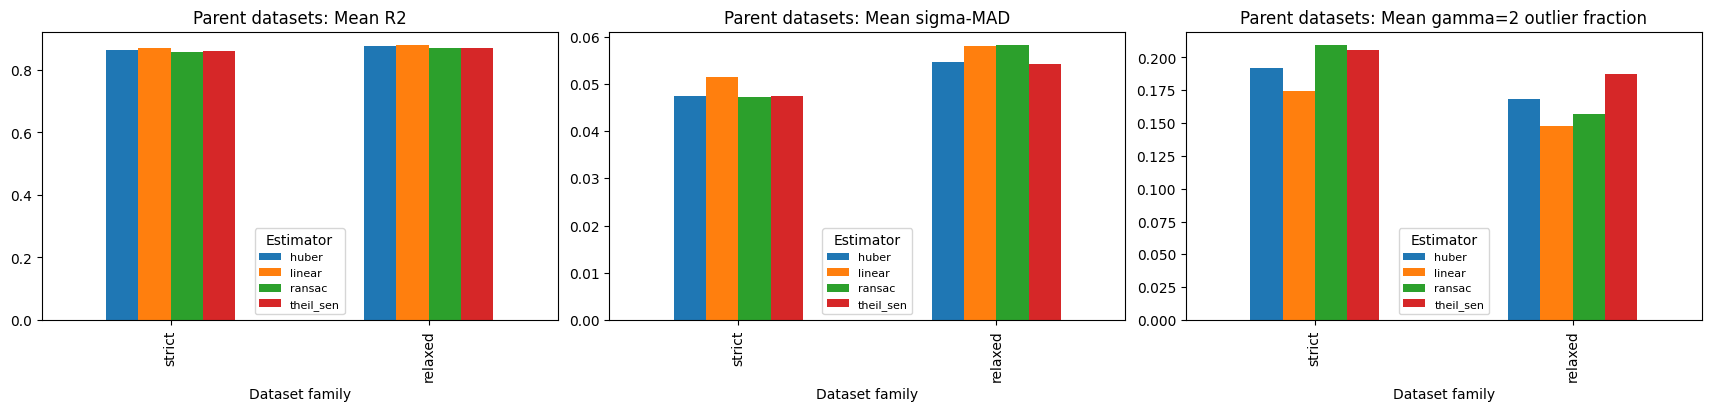

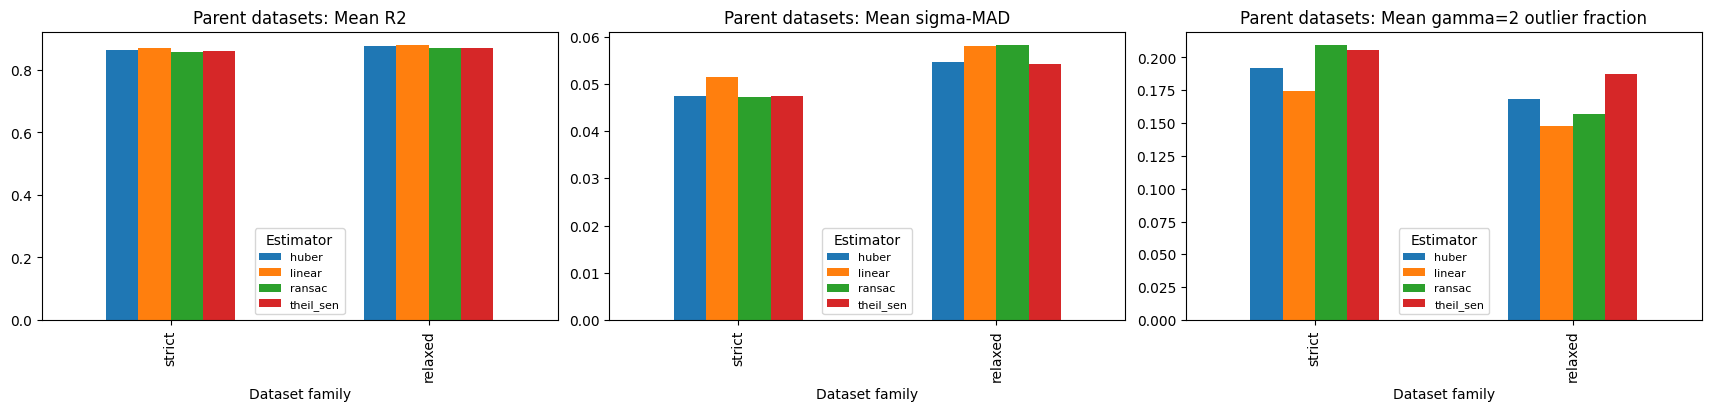

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)
main = estimator_summary[estimator_summary['astrometric_subset'] == 'photometry']
for metric, ax, title in [
    ('mean_r2', axes[0], 'Mean R2'),
    ('mean_sigma_mad', axes[1], 'Mean sigma-MAD'),
    ('mean_gamma2_outlier_fraction', axes[2], 'Mean gamma=2 outlier fraction'),
]:
    pivot = main.pivot_table(index='dataset_family', columns='estimator', values=metric, aggfunc='first').loc[family_order]
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'Parent datasets: {title}')
    ax.set_xlabel('Dataset family')
    ax.legend(title='Estimator', fontsize=8)
fig

In [26]:
subdataset_estimator_table = estimator_summary.pivot_table(
    index=['dataset_family', 'astrometric_subset'],
    columns='estimator',
    values='mean_r2',
    aggfunc='first',
).reset_index()
subdataset_estimator_table

estimator,dataset_family,astrometric_subset,huber,linear,ransac,theil_sen
0,strict,photometry,0.864894,0.868489,0.857320,0.861330
1,strict,poe_3,0.843885,0.849058,0.825700,0.834253
2,relaxed,photometry,0.875438,0.878191,0.868944,0.870596
3,relaxed,poe_3,0.874846,0.877875,0.868477,0.865456


In [27]:
# Compact visual summary is shown above in estimator_summary.
# Keep the full per-plane estimator_comparison table available for detailed inspection.
estimator_comparison.sort_values(['dataset_family', 'astrometric_subset', 'plane', 'estimator'])

,dataset_variant,dataset_family,astrometric_subset,plane,estimator,n,slope,intercept,r2,sigma_mad,q975_threshold,gamma2_threshold,q975_outlier_fraction,gamma2_outlier_fraction
5,strict_photometry,strict,photometry,G_BP -> BP_RP,huber,306,-0.940133,0.433696,0.959238,0.026939,0.282030,0.053878,0.026144,0.228758
4,strict_photometry,strict,photometry,G_BP -> BP_RP,linear,306,-0.992693,0.382846,0.962005,0.038947,0.243863,0.077893,0.026144,0.173203
7,strict_photometry,strict,photometry,G_BP -> BP_RP,ransac,306,-0.907680,0.478434,0.952951,0.021975,0.316071,0.043951,0.026144,0.281046
6,strict_photometry,strict,photometry,G_BP -> BP_RP,theil_sen,306,-0.939714,0.443553,0.958334,0.026548,0.291260,0.053097,0.026144,0.248366
1,strict_photometry,strict,photometry,G_BP -> G_RP,huber,306,-0.424930,0.383813,0.774765,0.038075,0.307771,0.076150,0.026144,0.235294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,relaxed_poe_3,relaxed,poe_3,J_H -> J_K,theil_sen,218,1.218158,0.171946,0.913500,0.068793,0.196349,0.137586,0.027523,0.091743
89,relaxed_poe_3,relaxed,poe_3,J_K -> H_K,huber,218,0.611391,-0.021336,0.871587,0.068717,0.134318,0.137434,0.027523,0.018349
88,relaxed_poe_3,relaxed,poe_3,J_K -> H_K,linear,218,0.600830,-0.010869,0.872085,0.070497,0.131708,0.140995,0.027523,0.013761
91,relaxed_poe_3,relaxed,poe_3,J_K -> H_K,ransac,218,0.638094,-0.041143,0.868500,0.066312,0.139447,0.132623,0.027523,0.036697


## SIMBAD Type Retention

In [28]:
type_counts = []
for variant, (_, neg_base, _, neg_locus) in outputs.items():
    type_col = 'simbad_main_type'
    if type_col not in neg_base.columns:
        continue
    base_counts = neg_base[type_col].value_counts().rename_axis(type_col).reset_index(name='base_rows')
    kept_counts = neg_locus.loc[neg_locus['color_locus_keep'], type_col].value_counts().rename_axis(type_col).reset_index(name='kept_rows')
    merged = base_counts.merge(kept_counts, on=type_col, how='left').fillna({'kept_rows': 0})
    merged['kept_fraction'] = merged['kept_rows'] / merged['base_rows']
    for key, value in variant_metadata(variant).items():
        merged[key] = value
    type_counts.append(merged)

type_counts = ordered_summary(pd.concat(type_counts, ignore_index=True)) if type_counts else pd.DataFrame()
type_counts.sort_values(['dataset_family', 'astrometric_subset', 'base_rows'], ascending=[True, True, False]).head(60)

,simbad_main_type,base_rows,kept_rows,kept_fraction,dataset_variant,dataset_family,astrometric_subset
0,LP*,9496,1339,0.141007,strict_photometry,strict,photometry
1,Em*,8951,5810,0.649089,strict_photometry,strict,photometry
2,RG*,8628,779,0.090287,strict_photometry,strict,photometry
3,C*,7768,6328,0.814624,strict_photometry,strict,photometry
4,EB*,7531,4484,0.595406,strict_photometry,strict,photometry
5,Y*O,6075,4462,0.734486,strict_photometry,strict,photometry
6,Er*,5172,2491,0.481632,strict_photometry,strict,photometry
7,TT*,4934,2838,0.575193,strict_photometry,strict,photometry
8,Be*,1762,1306,0.741203,strict_photometry,strict,photometry
9,AB*,1574,683,0.433926,strict_photometry,strict,photometry


## Parent Dataset Locus Diagnostic Plots

These are the main visual diagnostics for the two parent photometry datasets. Subdataset results are summarized in the tables above so the notebook does not overfit the narrative to one astrometric subset.

In [29]:
def plot_locus_variant(variant, sample='both'):
    ref_base, neg_base, ref_locus, neg_locus = outputs[variant]
    fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)
    for ax, (x_color, y_color) in zip(axes.ravel(), planes):
        plane_name = f'{x_color}__{y_color}'.replace('-', '_')
        keep_col = f'color_locus_{plane_name}_keep'
        slope_col = f'color_locus_{plane_name}_slope'
        threshold_col = f'color_locus_{plane_name}_threshold'
        if keep_col not in ref_locus.columns:
            ax.set_title(f'{x_color} vs {y_color}: unavailable')
            ax.axis('off')
            continue

        if sample in ['both', 'simbad']:
            ax.scatter(neg_locus[x_color], neg_locus[y_color], s=4, alpha=0.10, label='SIMBAD non-WR')
        if sample in ['both', 'wr']:
            ax.scatter(ref_locus.loc[ref_locus[keep_col], x_color], ref_locus.loc[ref_locus[keep_col], y_color], s=18, alpha=0.75, label='WR kept')
            ax.scatter(ref_locus.loc[~ref_locus[keep_col], x_color], ref_locus.loc[~ref_locus[keep_col], y_color], s=36, facecolors='none', edgecolors='red', linewidths=1.1, label='WR plane outlier')

        x_min, x_max = ref_locus[x_color].quantile([0.01, 0.99])
        x_grid = np.linspace(x_min, x_max, 200)
        tx = transform_color_values(pd.Series(x_grid), transform=color_cfg['transform']).to_numpy()
        slope = float(ref_locus[slope_col].iloc[0])
        intercept = float(ref_locus[f'color_locus_{plane_name}_intercept'].iloc[0])
        threshold = float(ref_locus[threshold_col].iloc[0])
        pred_t = intercept + slope * tx
        y_mid = inverse_transform_color_values(pred_t, transform=color_cfg['transform'])
        y_low = inverse_transform_color_values(pred_t - threshold, transform=color_cfg['transform'])
        y_high = inverse_transform_color_values(pred_t + threshold, transform=color_cfg['transform'])
        ax.plot(x_grid, y_mid, color='black', linewidth=1.6, label='Huber fit')
        ax.plot(x_grid, y_low, color='black', linewidth=1.0, linestyle='--', label='cut band')
        ax.plot(x_grid, y_high, color='black', linewidth=1.0, linestyle='--')

        ax.set_xlabel(x_color)
        ax.set_ylabel(y_color)
        ax.set_title(f'{variant}: {x_color} -> {y_color}')
    axes.ravel()[0].legend(loc='best', fontsize=8)
    return fig

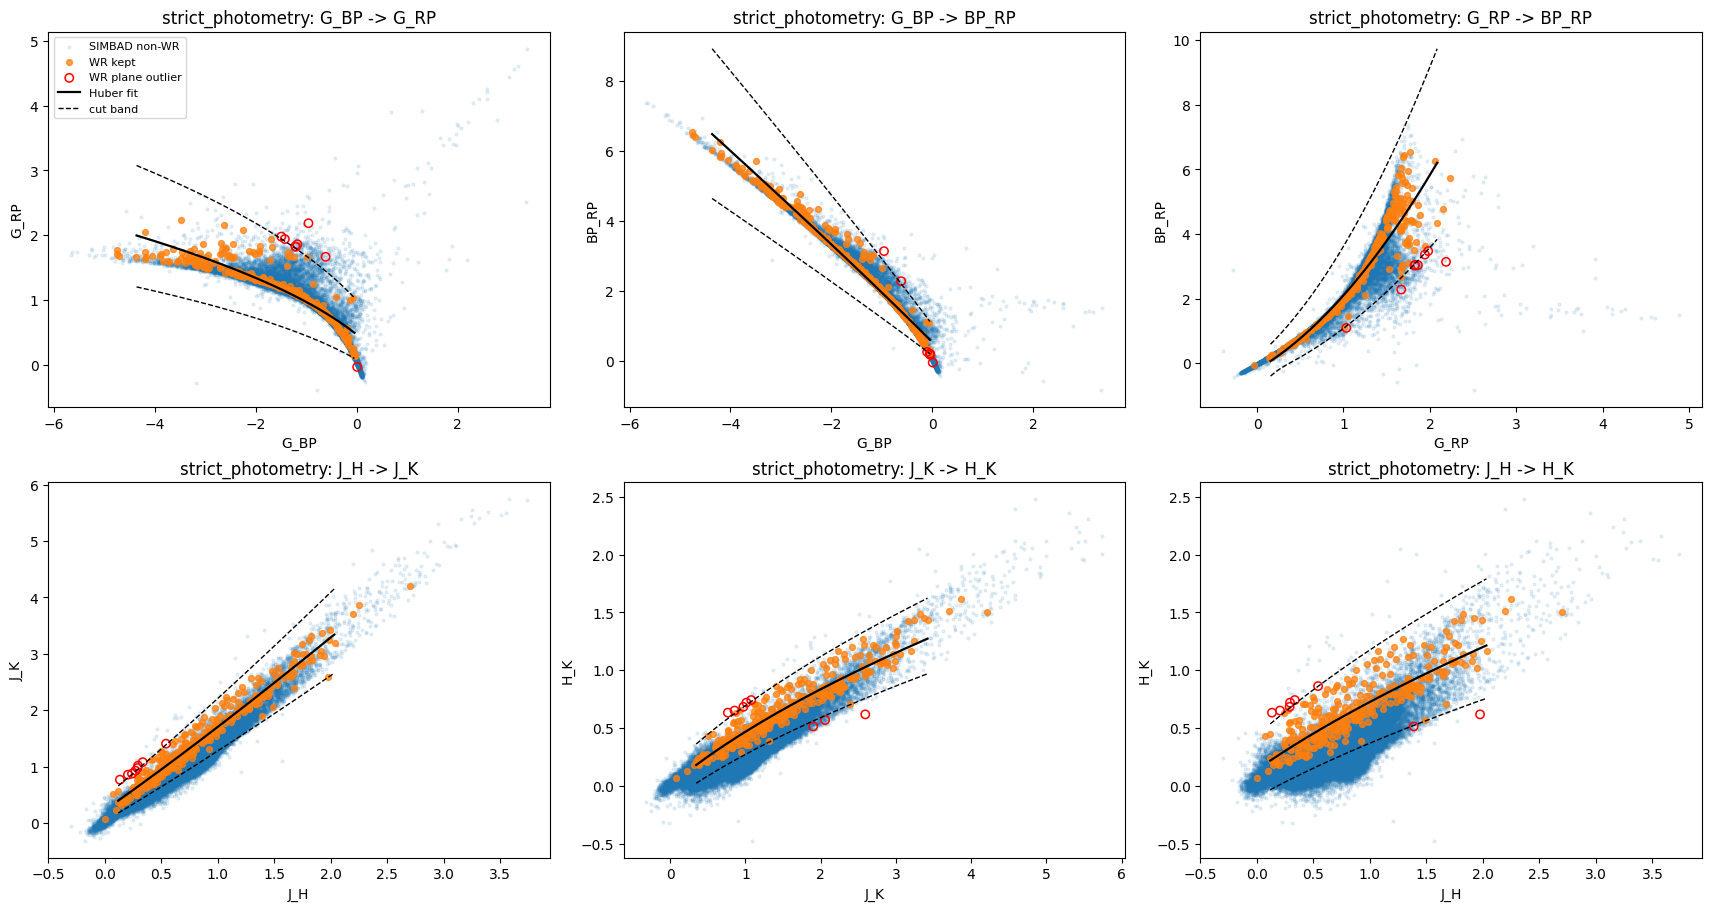

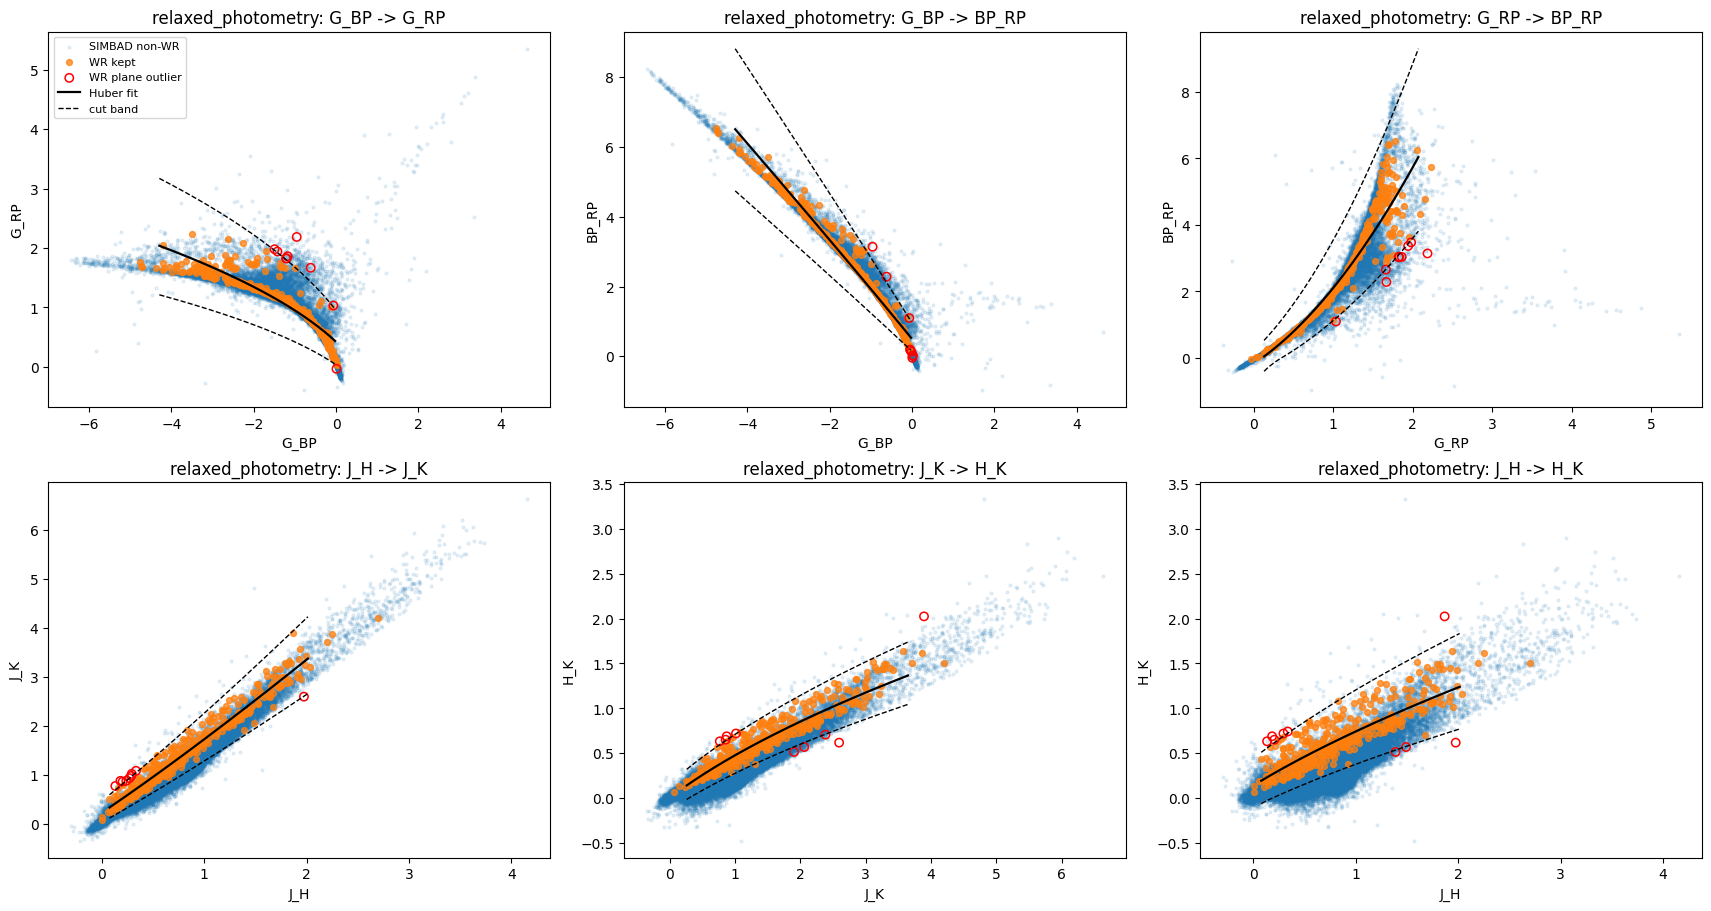

In [30]:
for variant in [v for v in ['strict_photometry', 'relaxed_photometry'] if v in outputs]:
    display(plot_locus_variant(variant))
    plt.close('all')

## Parent Dataset Residual Diagnostics

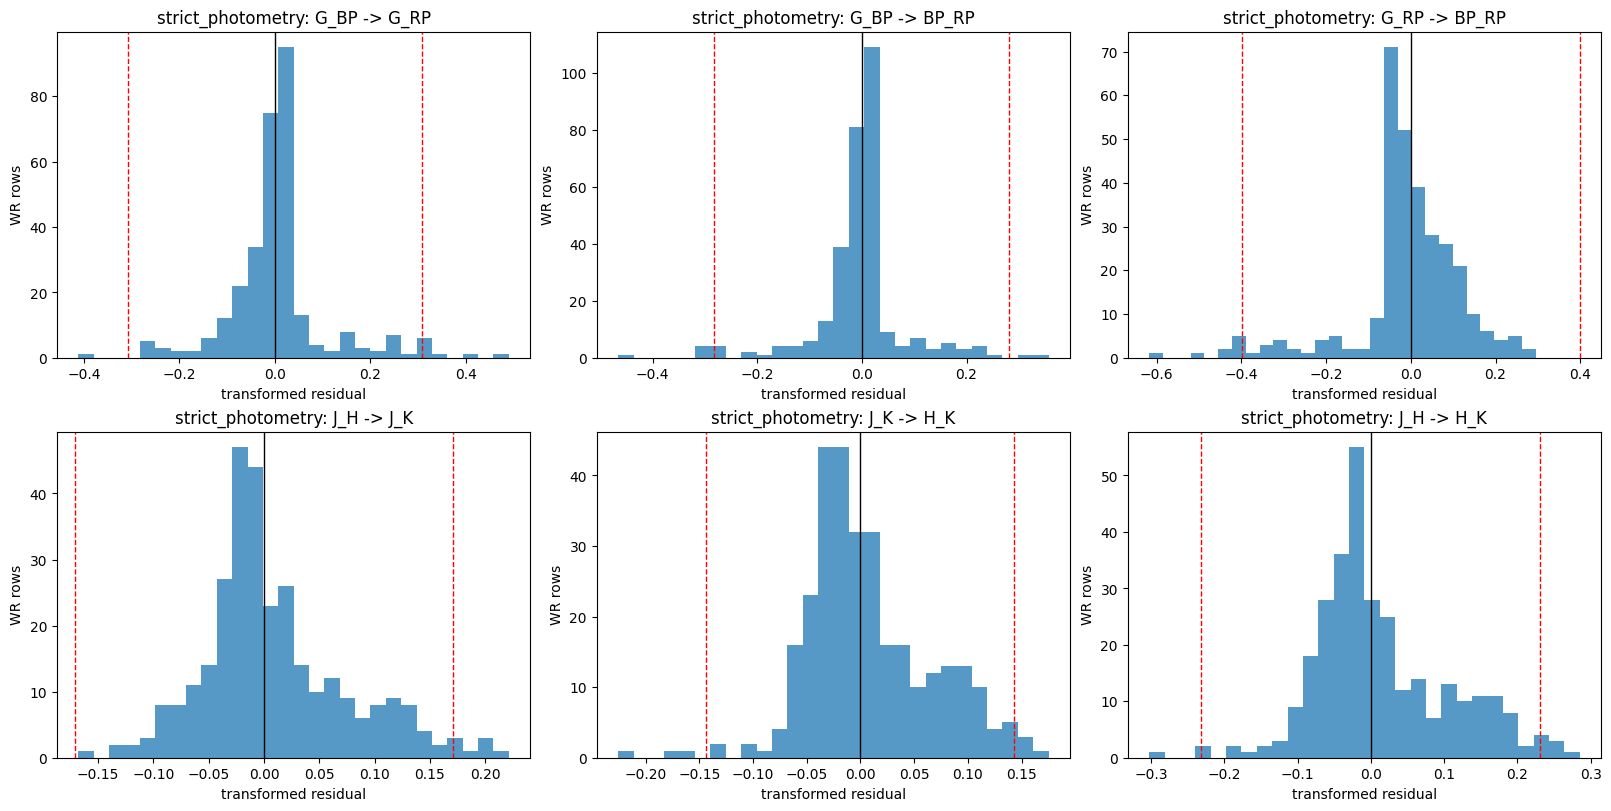

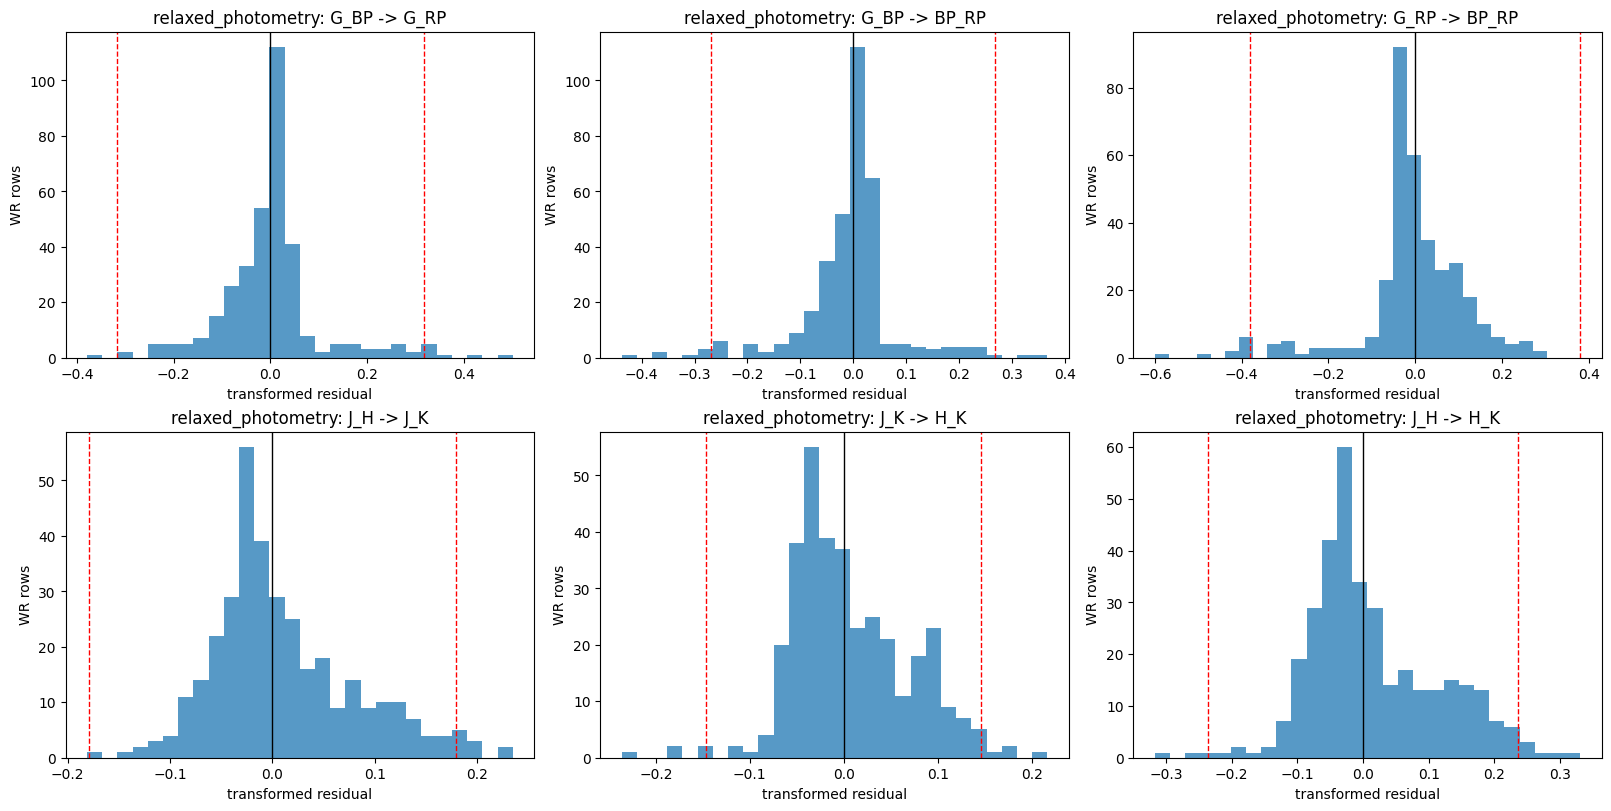

In [31]:
for variant in [v for v in ['strict_photometry', 'relaxed_photometry'] if v in outputs]:
    ref_locus = outputs[variant][2]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
    for ax, (x_color, y_color) in zip(axes.ravel(), planes):
        plane_name = f'{x_color}__{y_color}'.replace('-', '_')
        residual_col = f'color_locus_{plane_name}_residual'
        threshold_col = f'color_locus_{plane_name}_threshold'
        if residual_col not in ref_locus.columns:
            ax.axis('off')
            continue
        residual = ref_locus[residual_col].dropna()
        threshold = float(ref_locus[threshold_col].iloc[0])
        ax.hist(residual, bins=28, alpha=0.75)
        ax.axvline(-threshold, color='red', linestyle='--', linewidth=1)
        ax.axvline(threshold, color='red', linestyle='--', linewidth=1)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title(f'{variant}: {x_color} -> {y_color}')
        ax.set_xlabel('transformed residual')
        ax.set_ylabel('WR rows')
    plt.show()

## Phase 2 Note

The configured regression planes are intra-mission Gaia and 2MASS color-color planes. `W1_W2` remains available as an intra-mission WISE feature for reporting and modelling inputs, but it is not used as a Phase 2 regression plane because W3/W4 are not part of the required Phase 2 photometry.

## Formal Robust-Regression Assumption Audit

Short answer: the earlier notebook had useful visual and estimator-comparison diagnostics, but it did not fully audit the assumptions behind the robust linear color-locus model. The cells below add formal checks for linearity, heteroscedasticity, residual distribution, coefficient influence and fold-local stability.

In [32]:
from wr_detector.analysis.color_locus_assumptions import (
    bootstrap_huber_coefficients,
    compare_linear_quadratic_fit,
    fold_locus_stability,
    residual_assumption_summary,
)

assumption_rows = []
for variant, (_, _, ref_locus, _) in outputs.items():
    for x_color, y_color in planes:
        plane_name = f'{x_color}__{y_color}'.replace('-', '_')
        residual_col = f'color_locus_{plane_name}_residual'
        fitted_col = f'color_locus_{plane_name}_predicted_log_y'
        x_log_col = f'color_locus_{plane_name}_log_x'
        y_log_col = f'color_locus_{plane_name}_log_y'
        if residual_col not in ref_locus.columns:
            continue
        summary = residual_assumption_summary(ref_locus, residual_col, fitted_col, x_log_col)
        curvature = compare_linear_quadratic_fit(ref_locus[x_log_col], ref_locus[y_log_col])
        assumption_rows.append({
            **variant_metadata(variant),
            'plane': f'{x_color} -> {y_color}',
            **summary,
            **curvature,
        })
assumptions = pd.DataFrame(assumption_rows)
assumptions.sort_values(['quadratic_r2_gain', 'abs_residual_fitted_spearman'], ascending=False).head(30)

,dataset_variant,dataset_family,astrometric_subset,plane,n,residual_mean,residual_median,residual_sigma_mad,abs_residual_fitted_spearman,abs_residual_x_spearman,residual_fitted_spearman,residual_x_spearman,linear_r2,quadratic_r2,quadratic_r2_gain
36,relaxed_photometry,relaxed,photometry,G_BP -> G_RP,347,0.001916,0.008819,0.044789,-0.099417,0.099417,-0.003974,0.003974,0.806458,0.881888,0.075430
0,strict_photometry,strict,photometry,G_BP -> G_RP,306,0.005318,0.003248,0.038075,-0.040200,0.040200,0.001464,-0.001464,0.779768,0.854968,0.075200
48,relaxed_poe_1,relaxed,poe_1,G_BP -> G_RP,261,-0.011399,0.011454,0.040502,-0.208502,0.208502,0.006691,-0.006691,0.863440,0.933710,0.070270
12,strict_poe_1,strict,poe_1,G_BP -> G_RP,222,-0.011688,0.007557,0.029459,-0.121353,0.121353,0.030364,-0.030364,0.854475,0.923890,0.069415
42,relaxed_parallax_soft,relaxed,parallax_soft,G_BP -> G_RP,298,-0.008008,0.009458,0.041611,-0.141355,0.141355,0.013086,-0.013086,0.860494,0.927882,0.067388
6,strict_parallax_soft,strict,parallax_soft,G_BP -> G_RP,259,-0.007093,0.004311,0.033100,-0.068139,0.068139,0.025360,-0.025360,0.849412,0.915966,0.066554
60,relaxed_poe_3,relaxed,poe_3,G_BP -> G_RP,218,-0.012598,0.005880,0.045512,-0.268168,0.268168,0.000457,-0.000457,0.893121,0.948474,0.055353
24,strict_poe_3,strict,poe_3,G_BP -> G_RP,181,-0.014127,0.007942,0.033186,-0.231720,0.231720,-0.005482,0.005482,0.891456,0.946361,0.054905
54,relaxed_poe_2,relaxed,poe_2,G_BP -> G_RP,237,-0.012796,0.007357,0.044276,-0.243761,0.243761,-0.014716,0.014716,0.896092,0.949881,0.053789
30,strict_poe_5,strict,poe_5,G_BP -> G_RP,146,-0.011890,0.006610,0.035352,-0.220811,0.220811,0.016891,-0.016891,0.891352,0.945073,0.053721


In [33]:
# Coefficient influence by bootstrap for the parent relaxed photometry variant.
variant = 'relaxed_photometry' if 'relaxed_photometry' in outputs else next(iter(outputs))
ref_locus = outputs[variant][2]
bootstrap_rows = []
for x_color, y_color in planes:
    plane_name = f'{x_color}__{y_color}'.replace('-', '_')
    x_log_col = f'color_locus_{plane_name}_log_x'
    y_log_col = f'color_locus_{plane_name}_log_y'
    if x_log_col not in ref_locus.columns:
        continue
    boot = bootstrap_huber_coefficients(ref_locus[x_log_col], ref_locus[y_log_col], n_bootstrap=200)
    bootstrap_rows.append({
        'variant': variant,
        'plane': f'{x_color} -> {y_color}',
        'slope_p05': boot['slope'].quantile(0.05),
        'slope_p50': boot['slope'].quantile(0.50),
        'slope_p95': boot['slope'].quantile(0.95),
        'intercept_p05': boot['intercept'].quantile(0.05),
        'intercept_p50': boot['intercept'].quantile(0.50),
        'intercept_p95': boot['intercept'].quantile(0.95),
    })
bootstrap_summary = pd.DataFrame(bootstrap_rows)
bootstrap_summary

,variant,plane,slope_p05,slope_p50,slope_p95,intercept_p05,intercept_p50,intercept_p95
0,relaxed_photometry,G_BP -> G_RP,-0.484210,-0.456086,-0.426066,0.323526,0.350687,0.380502
1,relaxed_photometry,G_BP -> BP_RP,-0.994567,-0.966790,-0.943137,0.376410,0.405906,0.430093
2,relaxed_photometry,G_RP -> BP_RP,1.860452,1.908639,1.955291,-0.219699,-0.187550,-0.156686
3,relaxed_photometry,J_H -> J_K,1.135144,1.158078,1.179704,0.180518,0.198947,0.214443
4,relaxed_photometry,J_K -> H_K,0.541969,0.557394,0.575483,-0.010774,0.003980,0.016147
5,relaxed_photometry,J_H -> H_K,0.581194,0.609051,0.639845,0.112385,0.132569,0.152885


In [34]:
# Fold-local stability: fit each locus on train folds and score validation folds.
stability_rows = []
for x_color, y_color in planes:
    plane_name = f'{x_color}__{y_color}'.replace('-', '_')
    x_log_col = f'color_locus_{plane_name}_log_x'
    y_log_col = f'color_locus_{plane_name}_log_y'
    if x_log_col not in ref_locus.columns:
        continue
    stability = fold_locus_stability(ref_locus[x_log_col], ref_locus[y_log_col], n_splits=5)
    stability['variant'] = variant
    stability['plane'] = f'{x_color} -> {y_color}'
    stability_rows.append(stability)
fold_stability = pd.concat(stability_rows, ignore_index=True)
fold_stability.groupby('plane')[['train_r2', 'validation_r2', 'train_sigma_mad', 'validation_sigma_mad']].agg(['mean', 'std'])

train_r2           validation_r2           train_sigma_mad  \
                   mean       std          mean       std            mean   
plane                                                                       
G_BP -> BP_RP  0.960307  0.002226      0.957960  0.006449        0.035060   
G_BP -> G_RP   0.802836  0.016185      0.782315  0.078622        0.044886   
G_RP -> BP_RP  0.927059  0.007866      0.919518  0.039953        0.063223   
J_H -> H_K     0.722181  0.016665      0.717102  0.058157        0.075046   
J_H -> J_K     0.950614  0.002765      0.949581  0.009165        0.052621   
J_K -> H_K     0.888849  0.007366      0.886301  0.024756        0.054965   

                        validation_sigma_mad            
                    std                 mean       std  
plane                                                   
G_BP -> BP_RP  0.004328             0.033503  0.005313  
G_BP -> G_RP   0.005215             0.045060  0.007161  
G_RP -> BP_RP  0.004590             0.063409  0.019409  
J_H -> H_K     0.003633             0.076804  0.016305  
J_H -> J_K     0.002640             0.051650  0.007436  
J_K -> H_K     0.001719             0.056623  0.008620

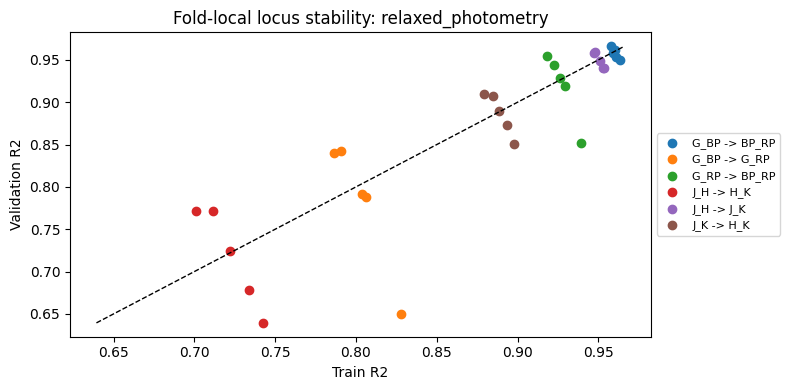

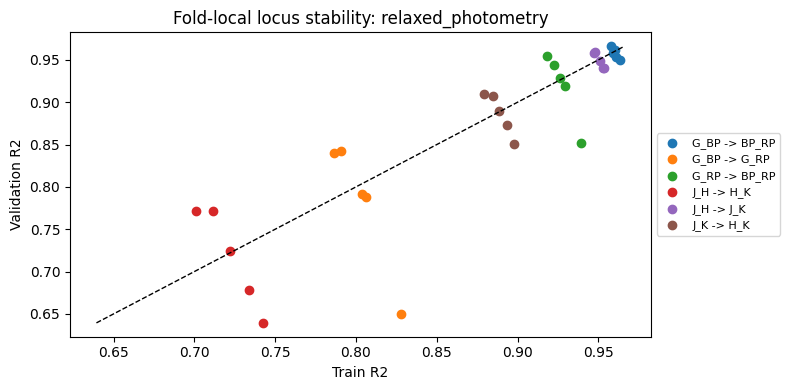

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
for plane, group in fold_stability.groupby('plane'):
    ax.scatter(group['train_r2'], group['validation_r2'], label=plane)
ax.plot([fold_stability[['train_r2', 'validation_r2']].min().min(), fold_stability[['train_r2', 'validation_r2']].max().max()],
        [fold_stability[['train_r2', 'validation_r2']].min().min(), fold_stability[['train_r2', 'validation_r2']].max().max()],
        color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Train R2')
ax.set_ylabel('Validation R2')
ax.set_title(f'Fold-local locus stability: {variant}')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
fig.tight_layout()
fig

## Final Cut Summary And RLR Consistency

This final section answers the operational questions after the full Phase 2 audit:

- Are the robust-linear-regression limits reasonable under their assumptions?
- What is retained for WR and non-WR in every exported dataset?
- Are the limits used in the color-locus export, model training and prediction pool the same?


In [36]:

# Final before/after table for every exported color-locus dataset.
final_rows = []
for variant, (ref_base, neg_base, ref_locus, neg_locus) in outputs.items():
    for sample, base, locus in [
        ('wr', ref_base, ref_locus),
        ('non_wr_simbad', neg_base, neg_locus),
    ]:
        rows_before = len(base)
        rows_after = int(locus['color_locus_keep'].sum()) if 'color_locus_keep' in locus else 0
        outliers = int((~locus['color_locus_keep'].astype(bool)).sum()) if 'color_locus_keep' in locus else rows_before - rows_after
        meta = variant_metadata(variant)
        final_rows.append({
            'dataset_variant': variant,
            'dataset_family': meta['dataset_family'],
            'astrometric_subset': meta['astrometric_subset'],
            'sample': sample,
            'rows_before_cut': rows_before,
            'rows_after_cut': rows_after,
            'rows_removed': rows_before - rows_after,
            'outlier_rows': outliers,
            'kept_pct': rows_after / rows_before if rows_before else np.nan,
        })

final_retention = pd.DataFrame(final_rows).sort_values(['sample', 'dataset_family', 'astrometric_subset'])
display(
    final_retention.style.format({
        'kept_pct': '{:.1%}',
    })
)


,dataset_variant,dataset_family,astrometric_subset,sample,rows_before_cut,rows_after_cut,rows_removed,outlier_rows,kept_pct
15,relaxed_parallax_soft,relaxed,parallax_soft,non_wr_simbad,53773,30049,23724,23724,55.9%
13,relaxed_photometry,relaxed,photometry,non_wr_simbad,66787,33343,33444,33444,49.9%
17,relaxed_poe_1,relaxed,poe_1,non_wr_simbad,48772,28613,20159,20159,58.7%
19,relaxed_poe_2,relaxed,poe_2,non_wr_simbad,45951,21489,24462,24462,46.8%
21,relaxed_poe_3,relaxed,poe_3,non_wr_simbad,44310,21344,22966,22966,48.2%
23,relaxed_poe_5,relaxed,poe_5,non_wr_simbad,41379,19435,21944,21944,47.0%
3,strict_parallax_soft,strict,parallax_soft,non_wr_simbad,50345,25933,24412,24412,51.5%
1,strict_photometry,strict,photometry,non_wr_simbad,62659,30906,31753,31753,49.3%
5,strict_poe_1,strict,poe_1,non_wr_simbad,45721,23614,22107,22107,51.6%
7,strict_poe_2,strict,poe_2,non_wr_simbad,43227,20363,22864,22864,47.1%


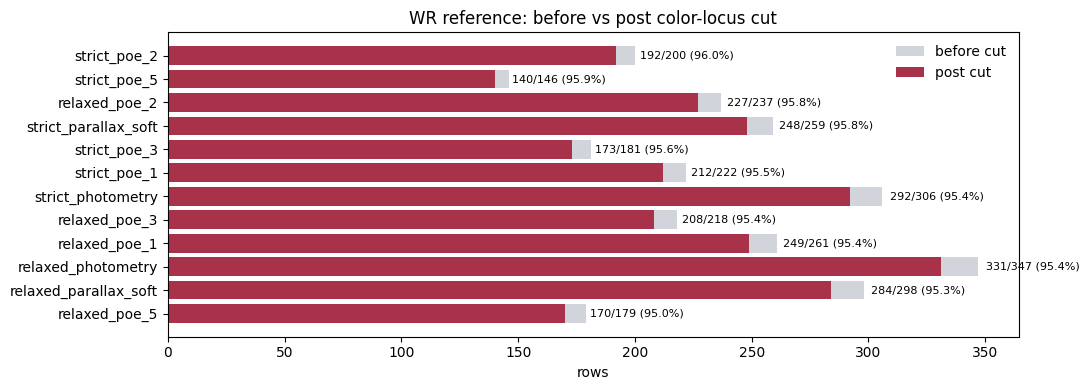

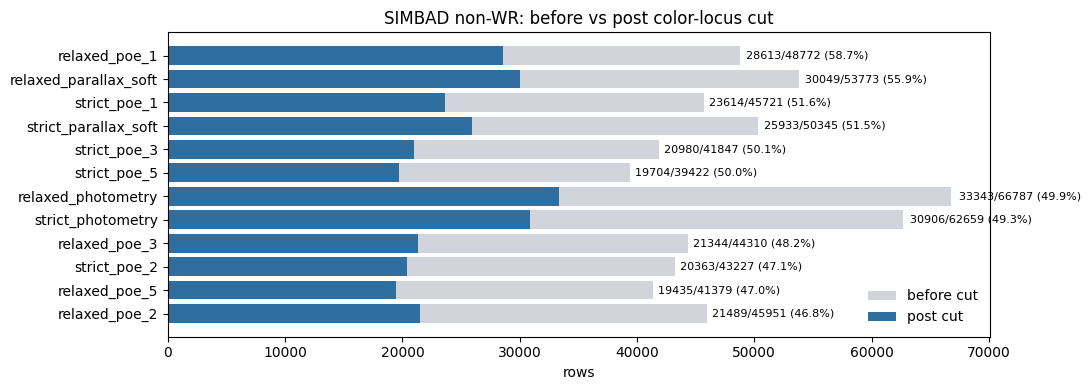

In [37]:

# Compact visual: before/post rows by sample, with kept percentage in labels.
plot = final_retention.copy()
plot['label'] = plot['dataset_variant']
for sample, title in [('wr', 'WR reference'), ('non_wr_simbad', 'SIMBAD non-WR')]:
    sub = plot[plot['sample'] == sample].sort_values('kept_pct')
    fig, ax = plt.subplots(figsize=(11, max(4, 0.32 * len(sub))))
    y = np.arange(len(sub))
    ax.barh(y, sub['rows_before_cut'], color='#D1D5DB', label='before cut')
    ax.barh(y, sub['rows_after_cut'], color='#2F6F9F' if sample == 'non_wr_simbad' else '#A8324A', label='post cut')
    for i, row in enumerate(sub.itertuples(index=False)):
        ax.text(row.rows_before_cut * 1.01, i, f'{row.rows_after_cut}/{row.rows_before_cut} ({row.kept_pct:.1%})', va='center', fontsize=8)
    ax.set_yticks(y, sub['label'])
    ax.set_xlabel('rows')
    ax.set_title(f'{title}: before vs post color-locus cut')
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [38]:
from IPython.display import Markdown


# Per-plane summary used for the assumptions readout.
assumption_summary = fits.groupby('plane').agg(
    variants=('dataset_variant', 'nunique'),
    median_r2=('r2', 'median'),
    min_r2=('r2', 'min'),
    median_sigma_mad=('sigma_mad', 'median'),
    max_threshold=('threshold', 'max'),
).reset_index().sort_values('median_r2', ascending=False)
display(assumption_summary.style.format({
    'median_r2': '{:.3f}',
    'min_r2': '{:.3f}',
    'median_sigma_mad': '{:.3f}',
    'max_threshold': '{:.3f}',
}))

wr_final = final_retention[final_retention['sample'] == 'wr']['kept_pct']
nonwr_final = final_retention[final_retention['sample'] == 'non_wr_simbad']['kept_pct']
display(Markdown(
    '\n'.join([
        '**Assumption readout:**',
        f'- WR retention stays high across variants: median `{wr_final.median():.1%}`, range `{wr_final.min():.1%}`-`{wr_final.max():.1%}`.',
        f'- SIMBAD non-WR retention is much lower: median `{nonwr_final.median():.1%}`, range `{nonwr_final.min():.1%}`-`{nonwr_final.max():.1%}`.',
        '- The RLR is valid as an operational robust locus diagnostic, not as a universal physical linear law.',
        '- Huber regression plus `signed_log1p` is appropriate here because it downweights strong deviations and supports negative Gaia colors.',
        '- The empirical quantile threshold is deliberately dataset-local; it should not be interpreted as a global sigma rule.',
    ])
))


,plane,variants,median_r2,min_r2,median_sigma_mad,max_threshold
0,G_BP -> BP_RP,12,0.965,0.959,0.034,0.282
2,G_RP -> BP_RP,12,0.965,0.910,0.049,0.399
4,J_H -> J_K,12,0.917,0.857,0.064,0.198
1,G_BP -> G_RP,12,0.871,0.775,0.039,0.317
5,J_K -> H_K,12,0.867,0.804,0.061,0.153
3,J_H -> H_K,12,0.635,0.441,0.087,0.255


**Assumption readout:**
- WR retention stays high across variants: median `95.5%`, range `95.0%`-`96.0%`.
- SIMBAD non-WR retention is much lower: median `50.0%`, range `46.8%`-`58.7%`.
- The RLR is valid as an operational robust locus diagnostic, not as a universal physical linear law.
- Huber regression plus `signed_log1p` is appropriate here because it downweights strong deviations and supports negative Gaia colors.
- The empirical quantile threshold is deliberately dataset-local; it should not be interpreted as a global sigma rule.

### Consistency Across Export, Training And Prediction Pool

The robust-linear-regression machinery is the same family of operation, but the **scope of the limits is not always the same**:

- **Color-locus export:** fits RLR separately for each configured dataset variant using that variant's WR reference rows. The output keeps all rows and writes `color_locus_keep` diagnostics.
- **Model training:** now loads each variant's own `_color_locus.parquet` and filters `color_locus_keep == True` before negative reduction, train/holdout split and SMOTE. Therefore training uses **per-dataset limits**, not the generalized prediction envelope.
- **Prediction pool:** uses a generalized envelope from relaxed variants (`relaxed_photometry`, `relaxed_parallax_soft`, `relaxed_poe_2`, `relaxed_poe_3`). ADQL uses rectangular color bounds from that union; local ingestion then applies generalized robust-locus checks and keeps rows with fewer than 2 outlier planes.

So: the model training limits are per dataset; the prediction pool limits are intentionally broader and generalized so candidate extraction is not tied to a single training variant.


In [39]:

# Machine-readable consistency table.
consistency = pd.DataFrame([
    {
        'stage': 'color_locus_export',
        'fit_scope': 'per dataset variant',
        'input_rows': 'WR reference of that variant',
        'cut_application': 'diagnostic columns; exports keep all rows',
        'kept_rule': 'color_locus_keep per variant',
    },
    {
        'stage': 'model_training',
        'fit_scope': 'per dataset variant',
        'input_rows': 'variant-specific _color_locus parquet',
        'cut_application': 'filters before reduction/split/training',
        'kept_rule': 'requires color_locus_keep == True',
    },
    {
        'stage': 'prediction_pool_adql',
        'fit_scope': 'generalized relaxed envelope',
        'input_rows': 'union of kept relaxed WR variants',
        'cut_application': 'server query rectangular color bounds',
        'kept_rule': 'color min/max bounds only when server_side_locus_filter is false',
    },
    {
        'stage': 'prediction_pool_local_ingest',
        'fit_scope': 'generalized relaxed envelope',
        'input_rows': 'downloaded Gaia tile rows',
        'cut_application': 'local robust-locus annotation before parquet insert',
        'kept_rule': 'valid colors and outlier_plane_count < 2',
    },
])
display(consistency)


,stage,fit_scope,input_rows,cut_application,kept_rule
0,color_locus_export,per dataset variant,WR reference of that variant,diagnostic columns; exports keep all rows,color_locus_keep per variant
1,model_training,per dataset variant,variant-specific _color_locus parquet,filters before reduction/split/training,requires color_locus_keep == True
2,prediction_pool_adql,generalized relaxed envelope,union of kept relaxed WR variants,server query rectangular color bounds,color min/max bounds only when server_side_loc...
3,prediction_pool_local_ingest,generalized relaxed envelope,downloaded Gaia tile rows,local robust-locus annotation before parquet i...,valid colors and outlier_plane_count < 2
